In [20]:
# ====================== REWS time series — setup block ======================
import os, re, glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from datetime import datetime, timedelta

# ============================================================
# Journal fonts & math — same style as your existing figures
# ============================================================
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "mathtext.fontset": "dejavusans",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
    "figure.titlesize": 10,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# ============================================================
# Layout & export preferences
# REWS figure first: 1 row × 3 panels
# ============================================================
FIGSIZE_1x3 = (6.85, 2.9)
DPI_PNG = 300

# ============================================================
# Data roots — same as your current code
# ============================================================
BASE_DIR_3DPBL = "/glade/work/mhafsah/Analysis_Proj_1/WS_all_runs"   # only 9 3DPBL runs
BASE_DIR_MAIN  = "/glade/work/mhafsah/Analysis_Proj_1/WS_d02"        # everything else

# ============================================================
# Output root
# ============================================================
OUT_ROOT = "timeseries_rews_vert54"

# ============================================================
# Locations and configuration labels
# ============================================================
LOCATIONS = ["E05", "E06"]
ICBCS     = ["era5", "gfs", "hrrr"]
PBLS      = ["ysu", "myj", "mynn", "3dpbl"]

# ============================================================
# Use only one vertical-resolution configuration
# vert54 = 10_194
# Other vertical-resolution runs are not used in this figure.
# ============================================================
TARGET_VERT = "54"
TARGET_VERT_LABEL = "10_194"

# ============================================================
# Observed/model height levels
# Arrays are expected to be shape (time, height)
# with heights 20, 40, ..., 200 m
# ============================================================
HEIGHTS = np.arange(20.0, 201.0, 20.0)

# ============================================================
# Turbine geometry
# 12 MW turbine:
# hub height = 138 m
# rotor diameter = 215 m
# full rotor layer = 30.5–245.5 m
#
# We calculate observed-layer partial REWS over 30.5–200 m
# because lidar/model-comparison heights stop at 200 m.
# ============================================================
HUB_HEIGHT = 138.0       # m
ROTOR_DIAMETER = 215.0   # m
ROTOR_RADIUS = ROTOR_DIAMETER / 2.0

Z_ROTOR_BOTTOM   = HUB_HEIGHT - ROTOR_RADIUS      # 30.5 m
Z_ROTOR_TOP_FULL = HUB_HEIGHT + ROTOR_RADIUS      # 245.5 m

Z_REWS_BOTTOM = Z_ROTOR_BOTTOM                    # 30.5 m
Z_REWS_TOP    = 200.0                             # observed upper limit

# Constant air density for later WPD figure
RHO = 1.225  # kg m^-3

# ============================================================
# Time axis
# 55 samples, 10-min step from 14:00 UTC
# ============================================================
START_TIME = datetime(2020, 5, 15, 14, 0, 0)
STEP_MIN   = 10

def make_time_index(n, start_dt=START_TIME, step_min=STEP_MIN):
    return [start_dt + timedelta(minutes=i * step_min) for i in range(n)]

# ============================================================
# Colors and markers
#
# First REWS figure:
#   - 3 panels: ERA5, GFS, HRRR
#   - only vert54 / 10_194 runs
#   - color = PBL scheme
#   - black line = observed REWS
#
# ICBC markers are retained from your previous plotting structure
# for consistency and possible later use, but they are not essential
# in this 3-panel ICBC-separated figure.
# ============================================================

# ---- Colors by PBL scheme ----
pbl_color = {
    "ysu":   "#0072B2",
    "myj":   "#D55E00",
    "mynn":  "#009E73",
    "3dpbl": "#CC79A7",
}

# ---- Markers for ICBC / forcing dataset ----
icbc_marker = {
    "era5": "*",
    "gfs":  "^",
    "hrrr": "o",
}

# ---- Sorting order ----
ICBC_ORDER = {"era5": 0, "gfs": 1, "hrrr": 2}
PBL_ORDER  = {"ysu": 0, "myj": 1, "mynn": 2, "3dpbl": 3}
VERT_ORDER = {"54": 0, "80": 1, "93": 2}

# ============================================================
# File naming pattern
# Expected run directory format:
# era5_ysu_vert54
# gfs_mynn_vert80
# hrrr_3dpbl_vert93
#
# The indexing block will keep only TARGET_VERT = "54".
# ============================================================
run_dir_pat = re.compile(
    r'^(?P<icbc>era5|gfs|hrrr)_(?P<pbl>ysu|myj|mynn|3dpbl)_vert(?P<vert>54|80|93)$'
)

print("Setup complete.")
print(f"Using only vertical configuration: vert{TARGET_VERT} = {TARGET_VERT_LABEL}")
print(f"REWS layer: {Z_REWS_BOTTOM:.1f}–{Z_REWS_TOP:.1f} m")
print(f"Full 12 MW rotor layer: {Z_ROTOR_BOTTOM:.1f}–{Z_ROTOR_TOP_FULL:.1f} m")
print(f"Output directory: {OUT_ROOT}")
print("Figure style: REWS only, 3 panels grouped by ERA5 / GFS / HRRR")

Setup complete.
Using only vertical configuration: vert54 = 10_194
REWS layer: 30.5–200.0 m
Full 12 MW rotor layer: 30.5–245.5 m
Output directory: timeseries_rews_vert54
Figure style: REWS only, 3 panels grouped by ERA5 / GFS / HRRR


In [21]:
# ====================== Block 2: index files and load WS profiles ======================

def index_files():
    """
    Recursive indexing:
      - search for WS_E05.npy / WS_E06.npy anywhere under each root
      - infer (icbc, pbl, vert) from parent directory name like era5_ysu_vert54
      - keep only TARGET_VERT = "54"
      - enforce:
          WS_all_runs -> only 3DPBL
          WS_d02      -> everything except 3DPBL
    """
    out = []

    def scan_root(root, allow_pbl=None, skip_pbl=None):
        for loc in LOCATIONS:
            pattern = os.path.join(root, "**", f"WS_{loc}.npy")

            for f in glob.glob(pattern, recursive=True):
                run_dir = os.path.basename(os.path.dirname(f))
                m = run_dir_pat.match(run_dir)

                if not m:
                    continue

                g = m.groupdict()
                icbc, pbl, vert = g["icbc"], g["pbl"], g["vert"]

                # Keep only vert54 / 10_194
                if vert != TARGET_VERT:
                    continue

                if allow_pbl is not None and pbl not in allow_pbl:
                    continue

                if skip_pbl is not None and pbl in skip_pbl:
                    continue

                out.append((f, icbc, pbl, vert, loc))

    scan_root(BASE_DIR_3DPBL, allow_pbl={"3dpbl"})
    scan_root(BASE_DIR_MAIN, skip_pbl={"3dpbl"})

    out.sort(key=lambda x: (
        x[4],                              # location
        ICBC_ORDER.get(x[1], 99),          # icbc
        PBL_ORDER.get(x[2], 99),           # pbl
        os.path.basename(os.path.dirname(x[0]))
    ))

    return out


def load_ws_profile(path):
    """
    Load full wind-speed profile array.

    Expected shape:
      (time, height) = (55, 10)

    Heights are:
      20, 40, ..., 200 m

    Returns:
      ws_profile with shape (time, 10)
    """
    arr = np.load(path)

    if arr.ndim != 2:
        raise ValueError(f"Expected 2-D array (time, height), got shape {arr.shape} in {path}")

    # Normal case: (time, 10)
    if arr.shape[1] == len(HEIGHTS):
        return arr.astype(float)

    # Backup case: accidentally stored as (10, time)
    if arr.shape[0] == len(HEIGHTS):
        print(f"Transposing array from {arr.shape} to {(arr.shape[1], arr.shape[0])}: {path}")
        return arr.T.astype(float)

    raise ValueError(
        f"Unexpected WS array shape {arr.shape} in {path}. "
        f"Expected one dimension to match {len(HEIGHTS)} height levels."
    )


def find_obs_ws_profile(loc):
    """
    Load WS_<loc>_OBS.npy as a full profile array.

    Search order:
      1) current working directory
      2) BASE_DIR_3DPBL direct
      3) BASE_DIR_MAIN direct
      4) recursive search under both roots

    Returns:
      observed WS profile with shape (time, 10), or None if not found.
    """
    filename = f"WS_{loc}_OBS.npy"

    # 1) current working directory
    here = os.path.join(os.getcwd(), filename)
    if os.path.exists(here):
        return load_ws_profile(here)

    # 2–4) search data roots
    for root in (BASE_DIR_3DPBL, BASE_DIR_MAIN):
        cand = os.path.join(root, filename)

        if os.path.exists(cand):
            return load_ws_profile(cand)

        hits = glob.glob(os.path.join(root, "**", filename), recursive=True)

        if hits:
            return load_ws_profile(hits[0])

    print(f"[{loc}] Observation file not found: {filename}")
    return None


def summarize_index(idx):
    """
    Print quick count summary for the indexed model files.
    """
    print(f"Total model files indexed: {len(idx)}")
    print(f"Using only vertical configuration: vert{TARGET_VERT} = {TARGET_VERT_LABEL}")

    for loc in LOCATIONS:
        print(f"\n{loc}:")
        for icbc in ICBCS:
            count_icbc = sum(1 for _, I, _, _, L in idx if L == loc and I == icbc)
            print(f"  {icbc.upper()}: {count_icbc} files")

            for pbl in PBLS:
                count_pbl = sum(
                    1 for _, I, P, _, L in idx
                    if L == loc and I == icbc and P == pbl
                )
                if count_pbl > 0:
                    print(f"    {pbl.upper():5s}: {count_pbl}")


# ====================== Test indexing/loading ======================
idx = index_files()
os.makedirs(OUT_ROOT, exist_ok=True)

summarize_index(idx)

for loc in LOCATIONS:
    obs = find_obs_ws_profile(loc)

    if obs is not None:
        print(f"\nObserved {loc}: shape = {obs.shape}")
    else:
        print(f"\nObserved {loc}: not found")

Total model files indexed: 24
Using only vertical configuration: vert54 = 10_194

E05:
  ERA5: 4 files
    YSU  : 1
    MYJ  : 1
    MYNN : 1
    3DPBL: 1
  GFS: 4 files
    YSU  : 1
    MYJ  : 1
    MYNN : 1
    3DPBL: 1
  HRRR: 4 files
    YSU  : 1
    MYJ  : 1
    MYNN : 1
    3DPBL: 1

E06:
  ERA5: 4 files
    YSU  : 1
    MYJ  : 1
    MYNN : 1
    3DPBL: 1
  GFS: 4 files
    YSU  : 1
    MYJ  : 1
    MYNN : 1
    3DPBL: 1
  HRRR: 4 files
    YSU  : 1
    MYJ  : 1
    MYNN : 1
    3DPBL: 1

Observed E05: shape = (55, 10)

Observed E06: shape = (55, 10)


In [22]:
# ====================== Block 3: calculate observed-layer REWS ======================

# Segment boundaries for partial observed-layer REWS.
# Bottom rotor tip is 30.5 m.
# Lidar/model heights are available every 20 m from 20 to 200 m.
#
# We interpolate wind speed at 30.5 m from the 20 and 40 m levels.
# Other boundaries are directly available from the 40–200 m levels.
REWS_BOUNDARIES = np.array(
    [Z_REWS_BOTTOM, 40.0, 60.0, 80.0, 100.0, 120.0, 140.0, 160.0, 180.0, Z_REWS_TOP],
    dtype=float
)

def rotor_width(z, hub_height=HUB_HEIGHT, rotor_radius=ROTOR_RADIUS):
    """
    Rotor-disk horizontal chord width at height z.

    w(z) = 2 * sqrt(R^2 - (z - z_h)^2)

    Only valid inside the rotor disk.
    """
    z = np.asarray(z, dtype=float)
    inside = rotor_radius**2 - (z - hub_height)**2
    return 2.0 * np.sqrt(np.maximum(inside, 0.0))


def segment_area(z1, z2, dz=0.05):
    """
    Numerically calculate rotor-disk area between z1 and z2.

    A_i = integral from z1 to z2 of w(z) dz
    """
    z_fine = np.arange(z1, z2 + dz, dz)

    # Make sure final point is exactly z2
    if z_fine[-1] > z2:
        z_fine[-1] = z2
    elif z_fine[-1] < z2:
        z_fine = np.append(z_fine, z2)

    w_fine = rotor_width(z_fine)

    # np.trapezoid is newer; np.trapz works on older numpy versions
    if hasattr(np, "trapezoid"):
        return np.trapezoid(w_fine, z_fine)
    else:
        return np.trapz(w_fine, z_fine)


# Area of each partial-rotor segment
REWS_SEGMENT_AREAS = np.array([
    segment_area(REWS_BOUNDARIES[i], REWS_BOUNDARIES[i + 1])
    for i in range(len(REWS_BOUNDARIES) - 1)
])

A_REWS_PARTIAL = np.sum(REWS_SEGMENT_AREAS)


def interp_profile_to_rews_boundaries(ws_profile_1d):
    """
    Interpolate one wind-speed profile to REWS_BOUNDARIES.

    Input:
      ws_profile_1d: wind-speed profile at HEIGHTS = 20, 40, ..., 200 m

    Output:
      wind speed at REWS_BOUNDARIES:
      30.5, 40, 60, ..., 200 m

    NaNs are ignored for interpolation. If the valid profile does not cover
    the full 30.5–200 m layer, return all NaNs.
    """
    ws_profile_1d = np.asarray(ws_profile_1d, dtype=float)
    valid = np.isfinite(ws_profile_1d) & np.isfinite(HEIGHTS)

    if valid.sum() < 2:
        return np.full_like(REWS_BOUNDARIES, np.nan, dtype=float)

    h_valid = HEIGHTS[valid]
    u_valid = ws_profile_1d[valid]

    # Need valid data covering the full REWS layer
    if h_valid.min() > Z_REWS_BOTTOM or h_valid.max() < Z_REWS_TOP:
        return np.full_like(REWS_BOUNDARIES, np.nan, dtype=float)

    return np.interp(REWS_BOUNDARIES, h_valid, u_valid)


def calculate_rews_from_ws_profile(ws_profile_2d):
    """
    Calculate observed-layer partial REWS for each time step.

    Uses Murphy-style segmented area-weighted cubic mean:

      U_REWS = [ sum_i A_i * Ubar_i^3 / sum_i A_i ]^(1/3)

    where:
      Ubar_i = average wind speed between adjacent segment boundaries
      A_i    = rotor-disk area between adjacent segment boundaries

    Input:
      ws_profile_2d: shape (time, height), heights = 20, 40, ..., 200 m

    Output:
      rews: shape (time,)
    """
    ws_profile_2d = np.asarray(ws_profile_2d, dtype=float)

    if ws_profile_2d.ndim != 2:
        raise ValueError(f"Expected 2-D wind-speed profile array, got {ws_profile_2d.shape}")

    rews = np.full(ws_profile_2d.shape[0], np.nan, dtype=float)

    for t in range(ws_profile_2d.shape[0]):
        u_b = interp_profile_to_rews_boundaries(ws_profile_2d[t, :])

        if not np.any(np.isfinite(u_b)):
            continue

        # Segment-mean wind speed between adjacent boundaries
        u_seg = 0.5 * (u_b[:-1] + u_b[1:])

        valid_seg = np.isfinite(u_seg)

        if valid_seg.sum() == 0:
            continue

        numerator = np.sum(REWS_SEGMENT_AREAS[valid_seg] * u_seg[valid_seg]**3)
        denominator = np.sum(REWS_SEGMENT_AREAS[valid_seg])

        if denominator > 0:
            rews[t] = (numerator / denominator) ** (1.0 / 3.0)

    return rews


def calculate_wpd_from_rews(rews, rho=RHO):
    """
    Wind-power-density proxy from REWS.

    This is not turbine electrical power output.
    It is available wind-power density based on observed-layer REWS.
    """
    rews = np.asarray(rews, dtype=float)
    return 0.5 * rho * rews**3


# ====================== Calculate REWS for obs and model runs ======================

def build_rews_dataset(idx):
    """
    Build dictionaries for observed and modeled REWS.

    Returns:
      obs_rews[loc] = observed REWS time series
      model_rews    = list of dictionaries, one per run
    """
    obs_rews = {}
    model_rews = []

    # Observed REWS
    for loc in LOCATIONS:
        obs_ws = find_obs_ws_profile(loc)

        if obs_ws is None:
            obs_rews[loc] = None
            continue

        obs_rews[loc] = calculate_rews_from_ws_profile(obs_ws)
        print(f"Observed REWS {loc}: shape = {obs_rews[loc].shape}")

    # Model REWS
    for f, icbc, pbl, vert, loc in idx:
        ws = load_ws_profile(f)
        rews = calculate_rews_from_ws_profile(ws)

        model_rews.append({
            "path": f,
            "icbc": icbc,
            "pbl": pbl,
            "vert": vert,
            "loc": loc,
            "rews": rews,
        })

    print(f"\nModel REWS calculated for {len(model_rews)} runs.")

    for loc in LOCATIONS:
        n_loc = sum(1 for d in model_rews if d["loc"] == loc)
        print(f"  {loc}: {n_loc} model REWS series")

    return obs_rews, model_rews


obs_rews, model_rews = build_rews_dataset(idx)

print("\nREWS calculation complete.")
print(f"REWS segment boundaries: {REWS_BOUNDARIES}")
print(f"Partial rotor area used: {A_REWS_PARTIAL:.2f} m^2")
print(f"Full rotor area would be: {np.pi * ROTOR_RADIUS**2:.2f} m^2")
print(f"Fraction of full rotor disk used: {100 * A_REWS_PARTIAL / (np.pi * ROTOR_RADIUS**2):.1f}%")

Observed REWS E05: shape = (55,)
Observed REWS E06: shape = (55,)

Model REWS calculated for 24 runs.
  E05: 12 model REWS series
  E06: 12 model REWS series

REWS calculation complete.
REWS segment boundaries: [ 30.5  40.   60.   80.  100.  120.  140.  160.  180.  200. ]
Partial rotor area used: 30701.31 m^2
Full rotor area would be: 36305.03 m^2
Fraction of full rotor disk used: 84.6%


Using REWS y-limits: (9.5, 22.5)


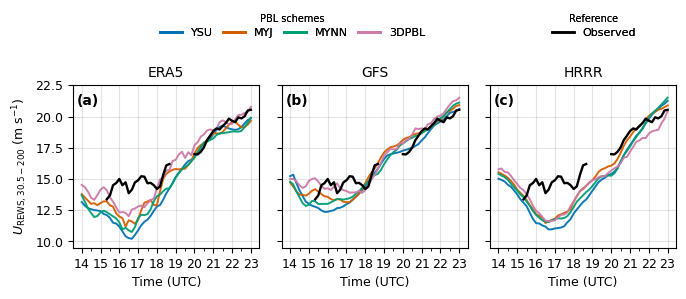

Saved: timeseries_rews_vert54/E05/rews_timeseries_1x3_E05_vert54.[pdf/png]


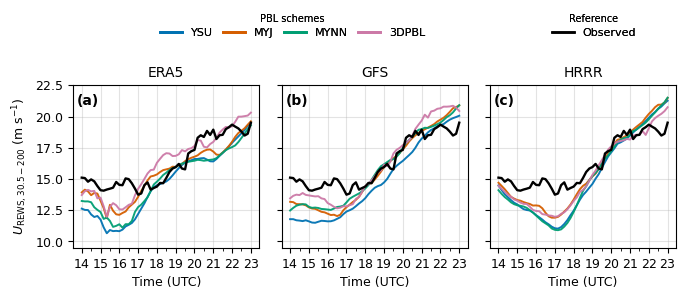

Saved: timeseries_rews_vert54/E06/rews_timeseries_1x3_E06_vert54.[pdf/png]
Done. Outputs in: timeseries_rews_vert54/E05 and timeseries_rews_vert54/E06


In [23]:
# ====================== Block 4: plot REWS time series, grouped by ICBC ======================

def ensure_outdir(loc):
    """
    Create output directory for each buoy/location.
    """
    outdir = os.path.join(OUT_ROOT, loc)
    os.makedirs(outdir, exist_ok=True)
    return outdir


def panel_label(ax, txt):
    """
    Add panel label such as (a), (b), (c).
    """
    ax.text(
        0.02, 0.95, txt,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=10, fontweight="bold"
    )


def style_time_axis(ax):
    """
    Match time-axis style from existing time-series figures.
    """
    ax.grid(True, alpha=0.35, linewidth=0.8)
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H"))
    ax.xaxis.set_minor_locator(mdates.MinuteLocator(byminute=[0, 30]))


def compute_rews_ylims(obs_rews, model_rews, pad=0.5):
    """
    Compute one common REWS y-axis range across both buoys and all model runs.

    This keeps E05 and E06 figures visually comparable.
    """
    vals = []

    # observed REWS
    for loc in LOCATIONS:
        if obs_rews.get(loc) is not None:
            vals.extend(np.asarray(obs_rews[loc]).ravel())

    # model REWS
    for d in model_rews:
        vals.extend(np.asarray(d["rews"]).ravel())

    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]

    if vals.size == 0:
        raise ValueError("No valid REWS values found for y-limit calculation.")

    ymin = np.floor((vals.min() - pad) * 2) / 2
    ymax = np.ceil((vals.max() + pad) * 2) / 2

    return (ymin, ymax)


def add_rews_legend(fig):
    """
    Top grouped legend:
      - PBL schemes
      - Reference
    """
    title_fs = 7
    label_fs = 8

    pbl_handles = [
        Line2D([0], [0], color=pbl_color[p], lw=2.0, linestyle="-", label=p.upper())
        for p in ["ysu", "myj", "mynn", "3dpbl"]
    ]

    ref_handles = [
        Line2D([0], [0], color="black", lw=1.8, linestyle="-", label="Observed")
    ]

    leg1 = fig.legend(
        handles=pbl_handles,
        loc="upper center",
        bbox_to_anchor=(0.42, 1.04),
        frameon=False,
        ncol=4,
        title="PBL schemes",
        title_fontsize=title_fs,
        fontsize=label_fs,
        handlelength=2.0,
        columnspacing=0.9,
        labelspacing=0.35,
        borderaxespad=0.0
    )

    leg2 = fig.legend(
        handles=ref_handles,
        loc="upper center",
        bbox_to_anchor=(0.86, 1.04),
        frameon=False,
        ncol=1,
        title="Reference",
        title_fontsize=title_fs,
        fontsize=label_fs,
        handlelength=2.0,
        columnspacing=0.9,
        labelspacing=0.35,
        borderaxespad=0.0
    )

    fig.add_artist(leg1)
    fig.add_artist(leg2)


def plot_rews_panel_by_icbc(ax, loc, icbc_fixed, obs_rews_loc, model_rews, t_ref, ylims, panel_txt):
    """
    Plot one ICBC/forcing panel.

    Panel title:
      ERA5 / GFS / HRRR

    Lines:
      one line per PBL scheme for TARGET_VERT only

    Color:
      PBL scheme

    Black:
      observed partial REWS
    """
    items = [
        d for d in model_rews
        if d["loc"] == loc
        and d["icbc"] == icbc_fixed
        and d["vert"] == TARGET_VERT
    ]

    items.sort(key=lambda d: (
        PBL_ORDER.get(d["pbl"], 99),
        os.path.basename(os.path.dirname(d["path"]))
    ))

    for d in items:
        y = d["rews"]
        pbl = d["pbl"]

        ax.plot(
            t_ref[:len(y)], y,
            color=pbl_color.get(pbl, "0.5"),
            linestyle="-",
            linewidth=1.4,
            alpha=0.95,
            label=pbl.upper()
        )

    if obs_rews_loc is not None:
        ax.plot(
            t_ref[:len(obs_rews_loc)], obs_rews_loc,
            color="black",
            linestyle="-",
            linewidth=1.7,
            zorder=5
        )

    ax.set_title(icbc_fixed.upper())
    ax.set_ylim(ylims)
    style_time_axis(ax)
    panel_label(ax, panel_txt)


def plot_rews_1x3_per_buoy(loc, obs_rews, model_rews, ylims):
    """
    Make one 1x3 REWS figure per buoy:

      (a) ERA5
      (b) GFS
      (c) HRRR

    Uses only vert54 / 10_194 data.
    """
    outdir = ensure_outdir(loc)

    # Determine maximum time length
    max_n = 0

    if obs_rews.get(loc) is not None:
        max_n = max(max_n, len(obs_rews[loc]))

    for d in model_rews:
        if d["loc"] == loc:
            max_n = max(max_n, len(d["rews"]))

    if max_n == 0:
        print(f"[{loc}] No REWS time series found.")
        return

    t_ref = make_time_index(max_n)

    fig, axs = plt.subplots(
        1, 3,
        figsize=FIGSIZE_1x3,
        sharex=True,
        sharey=True
    )

    fig.subplots_adjust(
        left=0.10,
        right=0.98,
        top=0.78,
        bottom=0.22,
        wspace=0.12
    )

    plot_rews_panel_by_icbc(
        axs[0], loc, "era5",
        obs_rews.get(loc),
        model_rews,
        t_ref,
        ylims,
        "(a)"
    )

    plot_rews_panel_by_icbc(
        axs[1], loc, "gfs",
        obs_rews.get(loc),
        model_rews,
        t_ref,
        ylims,
        "(b)"
    )

    plot_rews_panel_by_icbc(
        axs[2], loc, "hrrr",
        obs_rews.get(loc),
        model_rews,
        t_ref,
        ylims,
        "(c)"
    )

    axs[0].set_ylabel(r"$U_{\mathrm{REWS},30.5-200}$ (m s$^{-1}$)")

    for ax in axs:
        ax.set_xlabel("Time (UTC)")

    add_rews_legend(fig)

    base = f"rews_timeseries_1x3_{loc}_vert{TARGET_VERT}"

    fig.savefig(os.path.join(outdir, f"{base}.pdf"), bbox_inches="tight")
    fig.savefig(os.path.join(outdir, f"{base}.png"), dpi=DPI_PNG, bbox_inches="tight")

    plt.show()
    plt.close(fig)

    print(f"Saved: {os.path.join(outdir, base)}.[pdf/png]")


# ====================== RUN REWS FIGURES ======================

rews_ylims = compute_rews_ylims(obs_rews, model_rews, pad=0.5)
print(f"Using REWS y-limits: {rews_ylims}")

for loc in LOCATIONS:
    plot_rews_1x3_per_buoy(loc, obs_rews, model_rews, rews_ylims)

print(f"Done. Outputs in: {OUT_ROOT}/E05 and {OUT_ROOT}/E06")

Observed available power E05: shape = (55,)
Observed available power E06: shape = (55,)

Model available power calculated for 24 runs.
  E05: 12 model power series
  E06: 12 model power series
Using available-power y-limits: (0.0, 189.0)
Partial rotor area used for power calculation: 30701.31 m^2
Power quantity: available partial-rotor wind power, not turbine electrical output.


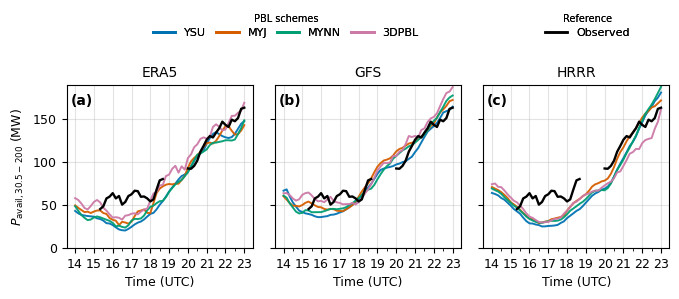

Saved: timeseries_rews_power_vert54/E05/available_power_timeseries_1x3_E05_vert54.[pdf/png]


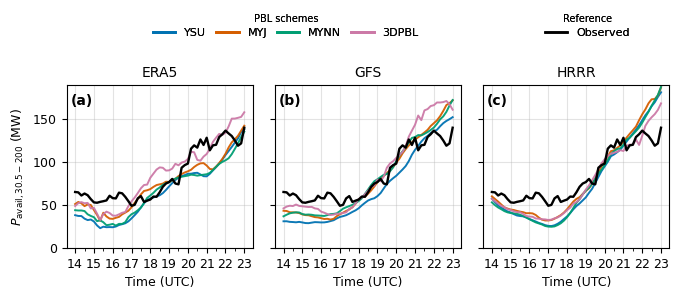

Saved: timeseries_rews_power_vert54/E06/available_power_timeseries_1x3_E06_vert54.[pdf/png]
Done. Outputs in: timeseries_rews_power_vert54/E05 and timeseries_rews_power_vert54/E06


In [24]:
# ====================== Block 5: REWS-based available power plots ======================

# Output folder for power figure
OUT_ROOT_POWER = "timeseries_rews_power_vert54"

def calculate_available_power_from_rews(rews, rho=RHO, area=A_REWS_PARTIAL):
    """
    Calculate REWS-based available partial-rotor wind power.

    P_avail = 0.5 * rho * A_partial * U_REWS^3

    Units:
      rho   = kg m^-3
      area  = m^2
      U     = m s^-1
      P     = W

    This is available wind power, not electrical turbine power output.
    """
    rews = np.asarray(rews, dtype=float)
    power_w = 0.5 * rho * area * rews**3
    power_mw = power_w / 1.0e6
    return power_mw


def build_power_dataset(obs_rews, model_rews):
    """
    Convert observed and modeled REWS time series to available power time series.

    Returns:
      obs_power[loc] = observed available power, MW
      model_power    = list of dictionaries, one per model run
    """
    obs_power = {}
    model_power = []

    # Observed power
    for loc in LOCATIONS:
        if obs_rews.get(loc) is None:
            obs_power[loc] = None
        else:
            obs_power[loc] = calculate_available_power_from_rews(obs_rews[loc])
            print(f"Observed available power {loc}: shape = {obs_power[loc].shape}")

    # Model power
    for d in model_rews:
        power_mw = calculate_available_power_from_rews(d["rews"])

        model_power.append({
            "path": d["path"],
            "icbc": d["icbc"],
            "pbl": d["pbl"],
            "vert": d["vert"],
            "loc": d["loc"],
            "power_mw": power_mw,
        })

    print(f"\nModel available power calculated for {len(model_power)} runs.")

    for loc in LOCATIONS:
        n_loc = sum(1 for d in model_power if d["loc"] == loc)
        print(f"  {loc}: {n_loc} model power series")

    return obs_power, model_power


def ensure_power_outdir(loc):
    """
    Create output directory for each buoy/location.
    """
    outdir = os.path.join(OUT_ROOT_POWER, loc)
    os.makedirs(outdir, exist_ok=True)
    return outdir


def compute_power_ylims(obs_power, model_power, pad=1.0):
    """
    Compute one common power y-axis range across both buoys and all model runs.

    This keeps E05 and E06 figures visually comparable.
    """
    vals = []

    # observed power
    for loc in LOCATIONS:
        if obs_power.get(loc) is not None:
            vals.extend(np.asarray(obs_power[loc]).ravel())

    # model power
    for d in model_power:
        vals.extend(np.asarray(d["power_mw"]).ravel())

    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]

    if vals.size == 0:
        raise ValueError("No valid power values found for y-limit calculation.")

    ymin = 0.0
    ymax = np.ceil(vals.max() + pad)

    return (ymin, ymax)


def add_power_legend(fig):
    """
    Top grouped legend:
      - PBL schemes
      - Reference
    """
    title_fs = 7
    label_fs = 8

    pbl_handles = [
        Line2D([0], [0], color=pbl_color[p], lw=2.0, linestyle="-", label=p.upper())
        for p in ["ysu", "myj", "mynn", "3dpbl"]
    ]

    ref_handles = [
        Line2D([0], [0], color="black", lw=1.8, linestyle="-", label="Observed")
    ]

    leg1 = fig.legend(
        handles=pbl_handles,
        loc="upper center",
        bbox_to_anchor=(0.42, 1.04),
        frameon=False,
        ncol=4,
        title="PBL schemes",
        title_fontsize=title_fs,
        fontsize=label_fs,
        handlelength=2.0,
        columnspacing=0.9,
        labelspacing=0.35,
        borderaxespad=0.0
    )

    leg2 = fig.legend(
        handles=ref_handles,
        loc="upper center",
        bbox_to_anchor=(0.86, 1.04),
        frameon=False,
        ncol=1,
        title="Reference",
        title_fontsize=title_fs,
        fontsize=label_fs,
        handlelength=2.0,
        columnspacing=0.9,
        labelspacing=0.35,
        borderaxespad=0.0
    )

    fig.add_artist(leg1)
    fig.add_artist(leg2)


def plot_power_panel_by_icbc(ax, loc, icbc_fixed, obs_power_loc, model_power, t_ref, ylims, panel_txt):
    """
    Plot one ICBC/forcing panel.

    Panel title:
      ERA5 / GFS / HRRR

    Lines:
      one line per PBL scheme for TARGET_VERT only

    Color:
      PBL scheme

    Black:
      observed REWS-based available power
    """
    items = [
        d for d in model_power
        if d["loc"] == loc
        and d["icbc"] == icbc_fixed
        and d["vert"] == TARGET_VERT
    ]

    items.sort(key=lambda d: (
        PBL_ORDER.get(d["pbl"], 99),
        os.path.basename(os.path.dirname(d["path"]))
    ))

    for d in items:
        y = d["power_mw"]
        pbl = d["pbl"]

        ax.plot(
            t_ref[:len(y)], y,
            color=pbl_color.get(pbl, "0.5"),
            linestyle="-",
            linewidth=1.4,
            alpha=0.95,
            label=pbl.upper()
        )

    if obs_power_loc is not None:
        ax.plot(
            t_ref[:len(obs_power_loc)], obs_power_loc,
            color="black",
            linestyle="-",
            linewidth=1.7,
            zorder=5
        )

    ax.set_title(icbc_fixed.upper())
    ax.set_ylim(ylims)
    style_time_axis(ax)
    panel_label(ax, panel_txt)


def plot_power_1x3_per_buoy(loc, obs_power, model_power, ylims):
    """
    Make one 1x3 available-power figure per buoy:

      (a) ERA5
      (b) GFS
      (c) HRRR

    Uses only vert54 / 10_194 data.
    """
    outdir = ensure_power_outdir(loc)

    # Determine maximum time length
    max_n = 0

    if obs_power.get(loc) is not None:
        max_n = max(max_n, len(obs_power[loc]))

    for d in model_power:
        if d["loc"] == loc:
            max_n = max(max_n, len(d["power_mw"]))

    if max_n == 0:
        print(f"[{loc}] No available-power time series found.")
        return

    t_ref = make_time_index(max_n)

    fig, axs = plt.subplots(
        1, 3,
        figsize=FIGSIZE_1x3,
        sharex=True,
        sharey=True
    )

    fig.subplots_adjust(
        left=0.10,
        right=0.98,
        top=0.78,
        bottom=0.22,
        wspace=0.12
    )

    plot_power_panel_by_icbc(
        axs[0], loc, "era5",
        obs_power.get(loc),
        model_power,
        t_ref,
        ylims,
        "(a)"
    )

    plot_power_panel_by_icbc(
        axs[1], loc, "gfs",
        obs_power.get(loc),
        model_power,
        t_ref,
        ylims,
        "(b)"
    )

    plot_power_panel_by_icbc(
        axs[2], loc, "hrrr",
        obs_power.get(loc),
        model_power,
        t_ref,
        ylims,
        "(c)"
    )

    axs[0].set_ylabel(r"$P_{\mathrm{avail},30.5-200}$ (MW)")

    for ax in axs:
        ax.set_xlabel("Time (UTC)")

    add_power_legend(fig)

    base = f"available_power_timeseries_1x3_{loc}_vert{TARGET_VERT}"

    fig.savefig(os.path.join(outdir, f"{base}.pdf"), bbox_inches="tight")
    fig.savefig(os.path.join(outdir, f"{base}.png"), dpi=DPI_PNG, bbox_inches="tight")

    plt.show()
    plt.close(fig)

    print(f"Saved: {os.path.join(outdir, base)}.[pdf/png]")


# ====================== RUN POWER FIGURES ======================

obs_power, model_power = build_power_dataset(obs_rews, model_rews)

os.makedirs(OUT_ROOT_POWER, exist_ok=True)

power_ylims = compute_power_ylims(obs_power, model_power, pad=1.0)
print(f"Using available-power y-limits: {power_ylims}")

print(f"Partial rotor area used for power calculation: {A_REWS_PARTIAL:.2f} m^2")
print("Power quantity: available partial-rotor wind power, not turbine electrical output.")

for loc in LOCATIONS:
    plot_power_1x3_per_buoy(loc, obs_power, model_power, power_ylims)

print(f"Done. Outputs in: {OUT_ROOT_POWER}/E05 and {OUT_ROOT_POWER}/E06")

Total model files indexed: 24
Using only vertical configuration: vert54 = 10_194

E05:
  ERA5: 4 files
    YSU  : 1
    MYJ  : 1
    MYNN : 1
    3DPBL: 1
  GFS: 4 files
    YSU  : 1
    MYJ  : 1
    MYNN : 1
    3DPBL: 1
  HRRR: 4 files
    YSU  : 1
    MYJ  : 1
    MYNN : 1
    3DPBL: 1

E06:
  ERA5: 4 files
    YSU  : 1
    MYJ  : 1
    MYNN : 1
    3DPBL: 1
  GFS: 4 files
    YSU  : 1
    MYJ  : 1
    MYNN : 1
    3DPBL: 1
  HRRR: 4 files
    YSU  : 1
    MYJ  : 1
    MYNN : 1
    3DPBL: 1

REWS setup:
Using only vertical configuration: vert54 = 10_194
Full rotor layer: 30.5–245.5 m
Lower-half REWS layer: 30.5–138.0 m
REWS boundaries: [ 30.5  40.   60.   80.  100.  120.  138. ]
Segment areas: [ 564.81 2435.41 3316.93 3838.86 4144.67 3851.84]
Calculated lower-half area: 18152.52 m^2
Exact lower-half area:      18152.52 m^2
Full rotor area:            36305.03 m^2
Fraction of full rotor:     50.00%
Observed lower-half REWS E05: shape = (55,)
Observed lower-half REWS E06: shape = (55,

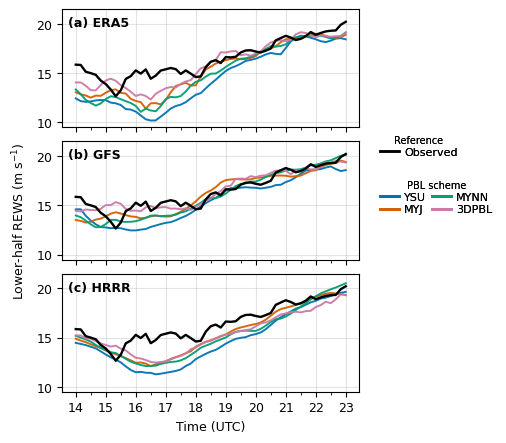

Saved: timeseries_rews_lower_half_vert54/E05/lower_half_rews_timeseries_1x3_E05_vert54.[pdf/png]


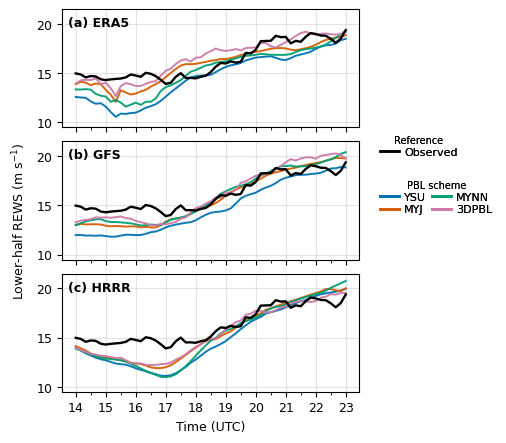

Saved: timeseries_rews_lower_half_vert54/E06/lower_half_rews_timeseries_1x3_E06_vert54.[pdf/png]

Done. Outputs in: timeseries_rews_lower_half_vert54/E05 and timeseries_rews_lower_half_vert54/E06


In [25]:
# ====================== Lower-half REWS time series — 3x1 panels ======================
import os
import re
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from datetime import datetime, timedelta


# ============================================================
# Journal fonts & math
# ============================================================

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "mathtext.fontset": "dejavusans",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
    "figure.titlesize": 10,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


# ============================================================
# Layout & export preferences
# ============================================================

# Same compact vertically stacked style as other time-series figures
FIGSIZE_3PAN = (5.5, 4.5)

DPI_PNG = 300


# ============================================================
# Data roots
# ============================================================

BASE_DIR_3DPBL = (
    "/glade/work/mhafsah/Analysis_Proj_1/WS_all_runs"
)   # only 9 3DPBL runs

BASE_DIR_MAIN = (
    "/glade/work/mhafsah/Analysis_Proj_1/WS_d02"
)   # everything else


# ============================================================
# Output root
# DO NOT CHANGE — keeps old folder name
# ============================================================

OUT_ROOT = "timeseries_rews_lower_half_vert54"


# ============================================================
# Locations and configuration labels
# ============================================================

LOCATIONS = ["E05", "E06"]

ICBCS = [
    "era5",
    "gfs",
    "hrrr",
]

PBLS = [
    "ysu",
    "myj",
    "mynn",
    "3dpbl",
]


# ============================================================
# Use only one vertical-resolution configuration
# vert54 = 10_194
# ============================================================

TARGET_VERT = "54"
TARGET_VERT_LABEL = "10_194"


# ============================================================
# Observed/model height levels
# Arrays expected:
#   shape = (time, height)
#   heights = 20, 40, ..., 200 m
# ============================================================

HEIGHTS = np.arange(
    20.0,
    201.0,
    20.0
)


# ============================================================
# Turbine geometry
#
# 12 MW turbine:
# hub height = 138 m
# rotor diameter = 215 m
#
# Full rotor:
# 30.5–245.5 m
#
# Lower-half REWS:
# 30.5–138 m
# ============================================================

HUB_HEIGHT = 138.0       # m
ROTOR_DIAMETER = 215.0   # m

ROTOR_RADIUS = (
    ROTOR_DIAMETER / 2.0
)

Z_ROTOR_BOTTOM = (
    HUB_HEIGHT - ROTOR_RADIUS
)   # 30.5 m

Z_ROTOR_TOP_FULL = (
    HUB_HEIGHT + ROTOR_RADIUS
)   # 245.5 m

Z_REWS_BOTTOM = (
    Z_ROTOR_BOTTOM
)   # 30.5 m

Z_REWS_TOP = (
    HUB_HEIGHT
)   # 138 m

REWS_LAYER_LABEL = "30.5-138"


# ============================================================
# Time axis
# 55 samples, 10-min step from 14:00 UTC
# ============================================================

START_TIME = datetime(
    2020,
    5,
    15,
    14,
    0,
    0
)

STEP_MIN = 10


def make_time_index(
    n,
    start_dt=START_TIME,
    step_min=STEP_MIN
):

    return [
        start_dt
        + timedelta(
            minutes=i * step_min
        )
        for i in range(n)
    ]


# ============================================================
# Colors
#
# Panels:
#   (a) ERA5
#   (b) GFS
#   (c) HRRR
#
# Color:
#   PBL scheme
#
# Black:
#   observed lower-half REWS
# ============================================================

pbl_color = {
    "ysu":   "#0072B2",
    "myj":   "#D55E00",
    "mynn":  "#009E73",
    "3dpbl": "#CC79A7",
}


ICBC_ORDER = {
    "era5": 0,
    "gfs": 1,
    "hrrr": 2,
}

PBL_ORDER = {
    "ysu": 0,
    "myj": 1,
    "mynn": 2,
    "3dpbl": 3,
}

VERT_ORDER = {
    "54": 0,
    "80": 1,
    "93": 2,
}


# ============================================================
# File naming pattern
#
# Expected run directories:
# era5_ysu_vert54
# gfs_mynn_vert80
# hrrr_3dpbl_vert93
# ============================================================

run_dir_pat = re.compile(
    r'^(?P<icbc>era5|gfs|hrrr)_'
    r'(?P<pbl>ysu|myj|mynn|3dpbl)_'
    r'vert(?P<vert>54|80|93)$'
)


# ============================================================
# File indexing
# ============================================================

def index_files():
    """
    Recursive indexing:

      - search WS_E05.npy / WS_E06.npy
      - infer ICBC, PBL, vertical configuration
        from parent-directory name
      - retain only TARGET_VERT = 54

    Data roots:
      WS_all_runs -> only 3DPBL
      WS_d02      -> everything except 3DPBL
    """

    out = []

    def scan_root(
        root,
        allow_pbl=None,
        skip_pbl=None
    ):

        for loc in LOCATIONS:

            pattern = os.path.join(
                root,
                "**",
                f"WS_{loc}.npy"
            )

            for f in glob.glob(
                pattern,
                recursive=True
            ):

                run_dir = os.path.basename(
                    os.path.dirname(f)
                )

                m = run_dir_pat.match(
                    run_dir
                )

                if not m:
                    continue

                g = m.groupdict()

                icbc = g["icbc"]
                pbl = g["pbl"]
                vert = g["vert"]

                # Only vert54 = 10_194
                if vert != TARGET_VERT:
                    continue

                if (
                    allow_pbl is not None
                    and pbl not in allow_pbl
                ):
                    continue

                if (
                    skip_pbl is not None
                    and pbl in skip_pbl
                ):
                    continue

                out.append(
                    (
                        f,
                        icbc,
                        pbl,
                        vert,
                        loc,
                    )
                )

    scan_root(
        BASE_DIR_3DPBL,
        allow_pbl={"3dpbl"}
    )

    scan_root(
        BASE_DIR_MAIN,
        skip_pbl={"3dpbl"}
    )

    out.sort(
        key=lambda x: (
            x[4],
            ICBC_ORDER.get(
                x[1],
                99
            ),
            PBL_ORDER.get(
                x[2],
                99
            ),
            os.path.basename(
                os.path.dirname(
                    x[0]
                )
            )
        )
    )

    return out


# ============================================================
# Load wind-speed profiles
# ============================================================

def load_ws_profile(path):
    """
    Load full wind-speed profile.

    Expected:
      shape = (time, height)
            = (55, 10)

    Heights:
      20, 40, ..., 200 m
    """

    arr = np.load(
        path
    )

    if arr.ndim != 2:

        raise ValueError(
            f"Expected 2-D array "
            f"(time, height), "
            f"got shape {arr.shape} "
            f"in {path}"
        )

    if arr.shape[1] == len(HEIGHTS):

        return arr.astype(
            float
        )

    if arr.shape[0] == len(HEIGHTS):

        print(
            f"Transposing array from "
            f"{arr.shape} to "
            f"{(arr.shape[1], arr.shape[0])}: "
            f"{path}"
        )

        return arr.T.astype(
            float
        )

    raise ValueError(
        f"Unexpected WS array shape "
        f"{arr.shape} in {path}. "
        f"Expected one dimension to "
        f"match {len(HEIGHTS)} height levels."
    )


# ============================================================
# Observations
# ============================================================

def find_obs_ws_profile(loc):
    """
    Load WS_<loc>_OBS.npy.

    Search order:
      1. current working directory
      2. BASE_DIR_3DPBL
      3. BASE_DIR_MAIN
      4. recursively under both roots
    """

    filename = (
        f"WS_{loc}_OBS.npy"
    )

    # Current directory
    here = os.path.join(
        os.getcwd(),
        filename
    )

    if os.path.exists(here):

        return load_ws_profile(
            here
        )

    # Search model roots
    for root in (
        BASE_DIR_3DPBL,
        BASE_DIR_MAIN
    ):

        candidate = os.path.join(
            root,
            filename
        )

        if os.path.exists(
            candidate
        ):

            return load_ws_profile(
                candidate
            )

        hits = glob.glob(
            os.path.join(
                root,
                "**",
                filename
            ),
            recursive=True
        )

        if hits:

            return load_ws_profile(
                hits[0]
            )

    print(
        f"[{loc}] Observation file "
        f"not found: {filename}"
    )

    return None


# ============================================================
# Print indexed files
# ============================================================

def summarize_index(idx):

    print(
        f"Total model files indexed: "
        f"{len(idx)}"
    )

    print(
        f"Using only vertical configuration: "
        f"vert{TARGET_VERT} = "
        f"{TARGET_VERT_LABEL}"
    )

    for loc in LOCATIONS:

        print(
            f"\n{loc}:"
        )

        for icbc in ICBCS:

            count_icbc = sum(
                1
                for _, I, _, _, L in idx
                if (
                    L == loc
                    and I == icbc
                )
            )

            print(
                f"  {icbc.upper()}: "
                f"{count_icbc} files"
            )

            for pbl in PBLS:

                count_pbl = sum(
                    1
                    for _, I, P, _, L in idx
                    if (
                        L == loc
                        and I == icbc
                        and P == pbl
                    )
                )

                if count_pbl > 0:

                    print(
                        f"    "
                        f"{pbl.upper():5s}: "
                        f"{count_pbl}"
                    )


# ============================================================
# Lower-half REWS calculation
# ============================================================

# Segment boundaries:
# 30.5–138 m
#
# 30.5 m interpolated between 20 and 40 m.
# 138 m interpolated between 120 and 140 m.

REWS_BOUNDARIES = np.array(
    [
        Z_REWS_BOTTOM,
        40.0,
        60.0,
        80.0,
        100.0,
        120.0,
        Z_REWS_TOP,
    ],
    dtype=float
)


# ============================================================
# Exact rotor-segment area
# ============================================================

def rotor_segment_area(
    z1,
    z2,
    hub_height=HUB_HEIGHT,
    rotor_radius=ROTOR_RADIUS
):
    """
    Exact analytical circular-rotor area
    between z1 and z2.

    Rotor width:

      w(z) = 2 sqrt[R^2 - (z-z_h)^2]

    Segment area:

      A_i = integral_z1^z2 w(z) dz
    """

    y1 = (
        z1 - hub_height
    )

    y2 = (
        z2 - hub_height
    )

    R = rotor_radius

    def F(y):

        y_clip = np.clip(
            y,
            -R,
            R
        )

        inside = np.maximum(
            R**2 - y_clip**2,
            0.0
        )

        return (
            y_clip
            * np.sqrt(inside)
            + R**2
            * np.arcsin(
                y_clip / R
            )
        )

    return (
        F(y2) - F(y1)
    )


REWS_SEGMENT_AREAS = np.array(
    [
        rotor_segment_area(
            REWS_BOUNDARIES[i],
            REWS_BOUNDARIES[i + 1]
        )
        for i in range(
            len(REWS_BOUNDARIES) - 1
        )
    ]
)

A_REWS_PARTIAL = np.sum(
    REWS_SEGMENT_AREAS
)

A_FULL_ROTOR = (
    np.pi
    * ROTOR_RADIUS**2
)

A_LOWER_HALF_EXACT = (
    0.5
    * A_FULL_ROTOR
)


# ============================================================
# Interpolate profile to lower-half REWS boundaries
# ============================================================

def interp_profile_to_rews_boundaries(
    ws_profile_1d
):
    """
    Input wind speeds:
      20, 40, ..., 200 m

    Output wind speeds:
      30.5, 40, 60, 80,
      100, 120, 138 m
    """

    ws_profile_1d = np.asarray(
        ws_profile_1d,
        dtype=float
    )

    valid = (
        np.isfinite(
            ws_profile_1d
        )
        & np.isfinite(
            HEIGHTS
        )
    )

    if valid.sum() < 2:

        return np.full_like(
            REWS_BOUNDARIES,
            np.nan,
            dtype=float
        )

    h_valid = (
        HEIGHTS[valid]
    )

    u_valid = (
        ws_profile_1d[valid]
    )

    # Need observations/model data
    # spanning full 30.5–138 m layer
    if (
        h_valid.min() > Z_REWS_BOTTOM
        or h_valid.max() < Z_REWS_TOP
    ):

        return np.full_like(
            REWS_BOUNDARIES,
            np.nan,
            dtype=float
        )

    return np.interp(
        REWS_BOUNDARIES,
        h_valid,
        u_valid
    )


# ============================================================
# Calculate REWS
# ============================================================

def calculate_rews_from_ws_profile(
    ws_profile_2d
):
    """
    Lower-half REWS:

      U_REWS =
      [sum(A_i U_i^3) / sum(A_i)]^(1/3)

    where:

      U_i =
      [U(z_i) + U(z_i+1)] / 2

    and A_i is the exact circular-rotor
    area between z_i and z_i+1.
    """

    ws_profile_2d = np.asarray(
        ws_profile_2d,
        dtype=float
    )

    if ws_profile_2d.ndim != 2:

        raise ValueError(
            f"Expected 2-D wind-speed "
            f"profile array, got "
            f"{ws_profile_2d.shape}"
        )

    rews = np.full(
        ws_profile_2d.shape[0],
        np.nan,
        dtype=float
    )

    for t in range(
        ws_profile_2d.shape[0]
    ):

        u_b = (
            interp_profile_to_rews_boundaries(
                ws_profile_2d[t, :]
            )
        )

        if not np.any(
            np.isfinite(u_b)
        ):
            continue

        # Representative wind speed
        # for each rotor segment
        u_seg = (
            0.5
            * (
                u_b[:-1]
                + u_b[1:]
            )
        )

        valid_seg = np.isfinite(
            u_seg
        )

        if valid_seg.sum() == 0:
            continue

        numerator = np.sum(
            REWS_SEGMENT_AREAS[
                valid_seg
            ]
            * u_seg[
                valid_seg
            ]**3
        )

        denominator = np.sum(
            REWS_SEGMENT_AREAS[
                valid_seg
            ]
        )

        if denominator > 0:

            rews[t] = (
                numerator
                / denominator
            ) ** (
                1.0 / 3.0
            )

    return rews


# ============================================================
# Build REWS datasets
# ============================================================

def build_rews_dataset(idx):
    """
    Returns:

      obs_rews[loc]
          observed lower-half REWS

      model_rews
          list of dictionaries,
          one per model run
    """

    obs_rews = {}

    model_rews = []

    # --------------------------------------------------------
    # Observations
    # --------------------------------------------------------

    for loc in LOCATIONS:

        obs_ws = (
            find_obs_ws_profile(
                loc
            )
        )

        if obs_ws is None:

            obs_rews[loc] = None
            continue

        obs_rews[loc] = (
            calculate_rews_from_ws_profile(
                obs_ws
            )
        )

        print(
            f"Observed lower-half REWS "
            f"{loc}: shape = "
            f"{obs_rews[loc].shape}"
        )

    # --------------------------------------------------------
    # Models
    # --------------------------------------------------------

    for (
        f,
        icbc,
        pbl,
        vert,
        loc
    ) in idx:

        ws = load_ws_profile(
            f
        )

        rews = (
            calculate_rews_from_ws_profile(
                ws
            )
        )

        model_rews.append({
            "path": f,
            "icbc": icbc,
            "pbl": pbl,
            "vert": vert,
            "loc": loc,
            "rews": rews,
        })

    print(
        f"\nModel lower-half REWS "
        f"calculated for "
        f"{len(model_rews)} runs."
    )

    for loc in LOCATIONS:

        n_loc = sum(
            1
            for d in model_rews
            if d["loc"] == loc
        )

        print(
            f"  {loc}: "
            f"{n_loc} model REWS series"
        )

    return (
        obs_rews,
        model_rews
    )


# ============================================================
# Plotting helpers
# ============================================================

def ensure_outdir(loc):

    outdir = os.path.join(
        OUT_ROOT,
        loc
    )

    os.makedirs(
        outdir,
        exist_ok=True
    )

    return outdir


def style_time_axis(ax):

    ax.grid(
        True,
        alpha=0.35,
        linewidth=0.8
    )

    ax.xaxis.set_major_locator(
        mdates.HourLocator(
            interval=1
        )
    )

    ax.xaxis.set_major_formatter(
        mdates.DateFormatter(
            "%H"
        )
    )

    ax.xaxis.set_minor_locator(
        mdates.MinuteLocator(
            byminute=[0, 30]
        )
    )


# ============================================================
# Common REWS y limits
# ============================================================

def compute_rews_ylims(
    obs_rews,
    model_rews,
    pad=0.5
):
    """
    One common REWS y-axis range
    across both buoys and all runs.
    """

    vals = []

    for loc in LOCATIONS:

        if obs_rews.get(
            loc
        ) is not None:

            vals.extend(
                np.asarray(
                    obs_rews[loc]
                ).ravel()
            )

    for d in model_rews:

        vals.extend(
            np.asarray(
                d["rews"]
            ).ravel()
        )

    vals = np.asarray(
        vals,
        dtype=float
    )

    vals = vals[
        np.isfinite(vals)
    ]

    if vals.size == 0:

        raise ValueError(
            "No valid REWS values "
            "found for y-limit calculation."
        )

    ymin = (
        np.floor(
            (
                vals.min()
                - pad
            ) * 2
        ) / 2
    )

    ymax = (
        np.ceil(
            (
                vals.max()
                + pad
            ) * 2
        ) / 2
    )

    return (
        ymin,
        ymax
    )


# ============================================================
# Right-side legends
# ============================================================

def add_rews_legend(fig):
    """
    Legends stacked vertically on right:

      1. Reference
      2. PBL scheme

    PBL options shown in 2 columns.
    """

    title_fs = 7
    label_fs = 8

    # --------------------------------------------------------
    # Reference
    # --------------------------------------------------------

    ref_handles = [
        Line2D(
            [0], [0],
            color="black",
            lw=1.8,
            linestyle="-",
            label="Observed"
        )
    ]

    # --------------------------------------------------------
    # PBL scheme
    # --------------------------------------------------------

    pbl_handles = [
        Line2D(
            [0], [0],
            color=pbl_color[p],
            lw=2.0,
            linestyle="-",
            label=(
                "3DPBL"
                if p == "3dpbl"
                else p.upper()
            )
        )
        for p in [
            "ysu",
            "myj",
            "mynn",
            "3dpbl"
        ]
    ]

    # --------------------------------------------------------
    # Reference legend
    # --------------------------------------------------------

    leg1 = fig.legend(
        handles=ref_handles,

        loc="upper left",

        bbox_to_anchor=(
            0.70,
            0.70
        ),

        frameon=False,

        ncol=1,

        title="Reference",
        title_fontsize=title_fs,
        fontsize=label_fs,

        handlelength=1.7,
        handletextpad=0.45,

        labelspacing=0.20,

        borderaxespad=0.0,
    )

    # --------------------------------------------------------
    # PBL legend
    # --------------------------------------------------------

    leg2 = fig.legend(
        handles=pbl_handles,

        loc="upper left",

        bbox_to_anchor=(
            0.70,
            0.60
        ),

        frameon=False,

        ncol=2,

        title="PBL scheme",
        title_fontsize=title_fs,
        fontsize=label_fs,

        handlelength=1.7,
        handletextpad=0.45,

        columnspacing=0.55,
        labelspacing=0.20,

        borderaxespad=0.0,
    )

    fig.add_artist(
        leg1
    )

    fig.add_artist(
        leg2
    )


# ============================================================
# Plot one forcing-dataset panel
# ============================================================

def plot_rews_panel_by_icbc(
    ax,
    loc,
    icbc_fixed,
    obs_rews_loc,
    model_rews,
    t_ref,
    ylims,
    panel_txt
):
    """
    One forcing-dataset panel.

    Panel:
      ERA5 / GFS / HRRR

    Lines:
      PBL schemes

    Vertical configuration:
      only vert54 = 10_194

    Black:
      observed lower-half REWS
    """

    items = [
        d
        for d in model_rews
        if (
            d["loc"] == loc
            and d["icbc"] == icbc_fixed
            and d["vert"] == TARGET_VERT
        )
    ]

    items.sort(
        key=lambda d: (
            PBL_ORDER.get(
                d["pbl"],
                99
            ),
            os.path.basename(
                os.path.dirname(
                    d["path"]
                )
            )
        )
    )

    # --------------------------------------------------------
    # Model lines
    # --------------------------------------------------------

    for d in items:

        y = d["rews"]
        pbl = d["pbl"]

        ax.plot(
            t_ref[:len(y)],
            y,

            color=pbl_color.get(
                pbl,
                "0.5"
            ),

            linestyle="-",

            linewidth=1.4,

            alpha=0.95
        )

    # --------------------------------------------------------
    # Observation
    # --------------------------------------------------------

    if obs_rews_loc is not None:

        ax.plot(
            t_ref[
                :len(obs_rews_loc)
            ],

            obs_rews_loc,

            color="black",

            linestyle="-",

            linewidth=1.7,

            zorder=5
        )

    # --------------------------------------------------------
    # Axis formatting
    # --------------------------------------------------------

    ax.set_ylim(
        ylims
    )

    style_time_axis(
        ax
    )

    # Panel label + forcing name together,
    # matching other vertically stacked figures
    ax.text(
        0.02,
        0.94,

        f"{panel_txt} "
        f"{icbc_fixed.upper()}",

        transform=ax.transAxes,

        ha="left",
        va="top",

        fontsize=9,
        fontweight="bold"
    )


# ============================================================
# 3x1 REWS figure
#
# IMPORTANT:
# Function name and output filename are intentionally retained
# so this replaces the existing horizontal figure.
# ============================================================

def plot_rews_1x3_per_buoy(
    loc,
    obs_rews,
    model_rews,
    ylims
):
    """
    New layout is 3x1:

      (a) ERA5
      (b) GFS
      (c) HRRR

    Output filename is intentionally unchanged.
    """

    outdir = ensure_outdir(
        loc
    )

    max_n = 0

    if obs_rews.get(
        loc
    ) is not None:

        max_n = max(
            max_n,
            len(
                obs_rews[loc]
            )
        )

    for d in model_rews:

        if d["loc"] == loc:

            max_n = max(
                max_n,
                len(
                    d["rews"]
                )
            )

    if max_n == 0:

        print(
            f"[{loc}] No REWS "
            f"time series found."
        )

        return

    t_ref = make_time_index(
        max_n
    )

    # --------------------------------------------------------
    # Figure
    # --------------------------------------------------------

    fig, axs = plt.subplots(
        3,
        1,

        figsize=FIGSIZE_3PAN,

        sharex=True,
        sharey=True
    )

    # Plotting panels on left,
    # legends on right
    fig.subplots_adjust(
        left=0.13,
        right=0.67,
        top=0.97,
        bottom=0.12,
        hspace=0.12
    )

    # --------------------------------------------------------
    # Shared y-axis label
    # --------------------------------------------------------

    fig.supylabel(
        r"Lower-half REWS (m s$^{-1}$)",
        fontsize=9,
        x=0.035
    )

    # --------------------------------------------------------
    # ERA5
    # --------------------------------------------------------

    plot_rews_panel_by_icbc(
        axs[0],
        loc,
        "era5",

        obs_rews.get(
            loc
        ),

        model_rews,
        t_ref,
        ylims,
        "(a)"
    )

    # --------------------------------------------------------
    # GFS
    # --------------------------------------------------------

    plot_rews_panel_by_icbc(
        axs[1],
        loc,
        "gfs",

        obs_rews.get(
            loc
        ),

        model_rews,
        t_ref,
        ylims,
        "(b)"
    )

    # --------------------------------------------------------
    # HRRR
    # --------------------------------------------------------

    plot_rews_panel_by_icbc(
        axs[2],
        loc,
        "hrrr",

        obs_rews.get(
            loc
        ),

        model_rews,
        t_ref,
        ylims,
        "(c)"
    )

    # Only bottom panel gets x-axis label
    axs[2].set_xlabel(
        "Time (UTC)"
    )

    # --------------------------------------------------------
    # Legends
    # --------------------------------------------------------

    add_rews_legend(
        fig
    )

    # --------------------------------------------------------
    # OUTPUT NAME
    #
    # DO NOT CHANGE:
    # keeps exactly the old horizontal-figure filename
    # so running this script overwrites the old files.
    # --------------------------------------------------------

    base = (
        f"lower_half_rews_timeseries_1x3_"
        f"{loc}_vert{TARGET_VERT}"
    )

    pdf_path = os.path.join(
        outdir,
        f"{base}.pdf"
    )

    png_path = os.path.join(
        outdir,
        f"{base}.png"
    )

    fig.savefig(
        pdf_path,
        bbox_inches="tight"
    )

    fig.savefig(
        png_path,
        dpi=DPI_PNG,
        bbox_inches="tight"
    )

    plt.show()

    plt.close(
        fig
    )

    print(
        f"Saved: "
        f"{os.path.join(outdir, base)}"
        f".[pdf/png]"
    )


# ============================================================
# RUN
# ============================================================

if __name__ == "__main__":

    idx = index_files()

    os.makedirs(
        OUT_ROOT,
        exist_ok=True
    )

    summarize_index(
        idx
    )

    print(
        "\nREWS setup:"
    )

    print(
        f"Using only vertical configuration: "
        f"vert{TARGET_VERT} = "
        f"{TARGET_VERT_LABEL}"
    )

    print(
        f"Full rotor layer: "
        f"{Z_ROTOR_BOTTOM:.1f}–"
        f"{Z_ROTOR_TOP_FULL:.1f} m"
    )

    print(
        f"Lower-half REWS layer: "
        f"{Z_REWS_BOTTOM:.1f}–"
        f"{Z_REWS_TOP:.1f} m"
    )

    print(
        f"REWS boundaries: "
        f"{REWS_BOUNDARIES}"
    )

    print(
        f"Segment areas: "
        f"{np.round(REWS_SEGMENT_AREAS, 2)}"
    )

    print(
        f"Calculated lower-half area: "
        f"{A_REWS_PARTIAL:.2f} m^2"
    )

    print(
        f"Exact lower-half area:      "
        f"{A_LOWER_HALF_EXACT:.2f} m^2"
    )

    print(
        f"Full rotor area:            "
        f"{A_FULL_ROTOR:.2f} m^2"
    )

    print(
        f"Fraction of full rotor:     "
        f"{100 * A_REWS_PARTIAL / A_FULL_ROTOR:.2f}%"
    )

    # --------------------------------------------------------
    # Calculate REWS
    # --------------------------------------------------------

    obs_rews, model_rews = (
        build_rews_dataset(
            idx
        )
    )

    # --------------------------------------------------------
    # Common y limits
    # --------------------------------------------------------

    rews_ylims = (
        compute_rews_ylims(
            obs_rews,
            model_rews,
            pad=0.5
        )
    )

    print(
        f"\nUsing REWS y-limits: "
        f"{rews_ylims}"
    )

    # --------------------------------------------------------
    # Plot E05 and E06
    # --------------------------------------------------------

    for loc in LOCATIONS:

        plot_rews_1x3_per_buoy(
            loc,
            obs_rews,
            model_rews,
            rews_ylims
        )

    print(
        f"\nDone. Outputs in: "
        f"{OUT_ROOT}/E05 and "
        f"{OUT_ROOT}/E06"
    )

In [26]:
# ====================== Block 1: event-alignment settings and helper functions ======================

# ============================================================
# Event-search settings
#
# The observed downramp minimum is identified between
# 14:00 and 18:00 UTC.
#
# For each model, the minimum is searched only from the
# observed-minimum time through 18:00 UTC.
# ============================================================
OBS_SEARCH_START = datetime(2020, 5, 15, 14, 0, 0)
SEARCH_END       = datetime(2020, 5, 15, 18, 0, 0)

# ============================================================
# Relative-time window for plotting and aligned metrics
#
# tau = 0 corresponds to the minimum of each individual series.
#
# Plot:
#   120 min before the minimum
#   180 min after the minimum
# ============================================================
TAU_MIN = -120
TAU_MAX = 180
TAU_STEP = 10

# Common relative-time grid used later for aligned metrics
COMMON_TAU = np.arange(
    TAU_MIN,
    TAU_MAX + TAU_STEP,
    TAU_STEP,
    dtype=float
)


def find_minimum_in_window(times, values, start_time, end_time):
    """
    Find the minimum finite value inside a specified time window.

    Parameters
    ----------
    times : array-like of datetime
        Original UTC timestamps.

    values : array-like
        REWS time series.

    start_time : datetime
        Beginning of the minimum-search window.

    end_time : datetime
        End of the minimum-search window.

    Returns
    -------
    min_index : int
        Index of the minimum in the original time series.

    min_time : datetime
        UTC timestamp associated with the minimum.

    min_value : float
        Minimum REWS value.
    """
    times = np.asarray(times)
    values = np.asarray(values, dtype=float)

    # Select points inside the requested time window
    window_mask = (
        (times >= start_time)
        & (times <= end_time)
        & np.isfinite(values)
    )

    valid_indices = np.where(window_mask)[0]

    if valid_indices.size == 0:
        raise ValueError(
            f"No finite values found between "
            f"{start_time.strftime('%H:%M')} and "
            f"{end_time.strftime('%H:%M')} UTC."
        )

    # Find the minimum among valid points in the search window
    local_min_position = np.argmin(values[valid_indices])

    # Convert back to index in the original full time series
    min_index = valid_indices[local_min_position]

    min_time = times[min_index]
    min_value = values[min_index]

    return min_index, min_time, min_value


def calculate_relative_time_minutes(times, reference_time):
    """
    Convert UTC timestamps to time relative to an event.

    tau = time - reference_time

    The output is in minutes.

    Examples
    --------
    60 min before the minimum:
        tau = -60

    At the minimum:
        tau = 0

    90 min after the minimum:
        tau = +90
    """
    return np.array([
        (t - reference_time).total_seconds() / 60.0
        for t in times
    ])


def interpolate_to_common_tau(tau, values, common_tau=COMMON_TAU):
    """
    Interpolate one event-relative REWS series onto the common
    relative-time grid.

    Values outside the available data range are assigned NaN.

    This will later allow every model to be evaluated using the
    same relative-time points.
    """
    tau = np.asarray(tau, dtype=float)
    values = np.asarray(values, dtype=float)

    valid = np.isfinite(tau) & np.isfinite(values)

    if valid.sum() < 2:
        return np.full(common_tau.shape, np.nan, dtype=float)

    tau_valid = tau[valid]
    values_valid = values[valid]

    # Sort in increasing relative time
    order = np.argsort(tau_valid)

    tau_valid = tau_valid[order]
    values_valid = values_valid[order]

    interpolated = np.interp(
        common_tau,
        tau_valid,
        values_valid,
        left=np.nan,
        right=np.nan
    )

    return interpolated


print("Alignment settings complete.")
print(
    f"Observed minimum search: "
    f"{OBS_SEARCH_START.strftime('%H:%M')}–"
    f"{SEARCH_END.strftime('%H:%M')} UTC"
)
print(
    f"Model minimum search: "
    f"observed-minimum time–"
    f"{SEARCH_END.strftime('%H:%M')} UTC"
)
print(
    f"Common relative-time window: "
    f"{TAU_MIN} to +{TAU_MAX} min"
)
print(f"Relative-time interval: {TAU_STEP} min")

Alignment settings complete.
Observed minimum search: 14:00–18:00 UTC
Model minimum search: observed-minimum time–18:00 UTC
Common relative-time window: -120 to +180 min
Relative-time interval: 10 min


In [11]:
# ====================== Block 2: identify minima and calculate timing lag ======================

alignment_results = {}

for loc in LOCATIONS:

    # --------------------------------------------------------
    # Observed REWS
    # --------------------------------------------------------
    obs_values = obs_rews.get(loc)

    if obs_values is None:
        print(f"[{loc}] Observed REWS not available.")
        continue

    obs_values = np.asarray(obs_values, dtype=float)
    obs_times = np.array(make_time_index(len(obs_values)))

    # Find observed REWS minimum within the previously defined window
    obs_min_index, obs_min_time, obs_min_value = find_minimum_in_window(
        times=obs_times,
        values=obs_values,
        start_time=OBS_SEARCH_START,
        end_time=SEARCH_END
    )

    # Relative time for observations
    # tau = 0 at the observed minimum
    obs_tau = calculate_relative_time_minutes(
        times=obs_times,
        reference_time=obs_min_time
    )

    # Store observed information
    alignment_results[loc] = {
        "observed": {
            "times": obs_times,
            "rews": obs_values,
            "min_index": obs_min_index,
            "min_time": obs_min_time,
            "min_value": obs_min_value,
            "tau": obs_tau,
        },
        "models": []
    }

    print("\n" + "=" * 70)
    print(f"{loc}")
    print("=" * 70)

    print(
        f"Observed minimum: "
        f"{obs_min_value:.3f} m s^-1 at "
        f"{obs_min_time.strftime('%H:%M UTC')}"
    )

    print("\nModel timing lags:")
    print(
        f"{'ICBC':<8}"
        f"{'PBL':<8}"
        f"{'Model minimum':<18}"
        f"{'Minimum REWS':<16}"
        f"{'Lag (min)':<10}"
    )

    print("-" * 70)

    # --------------------------------------------------------
    # Model REWS
    # --------------------------------------------------------
    model_items = [
        d for d in model_rews
        if d["loc"] == loc
        and d["vert"] == TARGET_VERT
    ]

    model_items.sort(
        key=lambda d: (
            ICBC_ORDER.get(d["icbc"], 99),
            PBL_ORDER.get(d["pbl"], 99)
        )
    )

    for d in model_items:

        model_values = np.asarray(d["rews"], dtype=float)
        model_times = np.array(make_time_index(len(model_values)))

        # Search the model minimum only from the
        # observed-minimum time through 18:00 UTC
        model_min_index, model_min_time, model_min_value = find_minimum_in_window(
            times=model_times,
            values=model_values,
            start_time=obs_min_time,
            end_time=SEARCH_END
        )

        # Lag is calculated relative to the observed minimum.
        #
    # Because the model minimum is searched only from the
    # observed-minimum time through 18:00 UTC:
    #
    #   lag = 0   -> model minimum occurs at the observed-minimum time
    #   lag > 0   -> model minimum occurs later than observed
    #
    # Negative lag cannot occur under this search rule.
        lag_minutes = (
            model_min_time - obs_min_time
        ).total_seconds() / 60.0

        # Relative time for this individual model
        # tau = 0 at this model's own minimum
        model_tau = calculate_relative_time_minutes(
            times=model_times,
            reference_time=model_min_time
        )

        # Store model information
        alignment_results[loc]["models"].append({
            "path": d["path"],
            "icbc": d["icbc"],
            "pbl": d["pbl"],
            "vert": d["vert"],
            "times": model_times,
            "rews": model_values,
            "min_index": model_min_index,
            "min_time": model_min_time,
            "min_value": model_min_value,
            "lag_minutes": lag_minutes,
            "tau": model_tau,
        })

        print(
            f"{d['icbc'].upper():<8}"
            f"{d['pbl'].upper():<8}"
            f"{model_min_time.strftime('%H:%M UTC'):<18}"
            f"{model_min_value:<16.3f}"
            f"{lag_minutes:<10.0f}"
        )

print("\nMinimum identification and lag calculation complete.")


E05
Observed minimum: 12.652 m s^-1 at 15:20 UTC

Model timing lags:
ICBC    PBL     Model minimum     Minimum REWS    Lag (min) 
----------------------------------------------------------------------
ERA5    YSU     16:30 UTC         10.186          70        
ERA5    MYJ     16:20 UTC         11.399          60        
ERA5    MYNN    16:10 UTC         11.068          50        
ERA5    3DPBL   16:30 UTC         12.324          70        
GFS     YSU     15:50 UTC         12.455          30        
GFS     MYJ     16:10 UTC         13.689          50        
GFS     MYNN    15:40 UTC         13.317          20        
GFS     3DPBL   16:10 UTC         14.401          50        
HRRR    YSU     16:40 UTC         11.269          80        
HRRR    MYJ     16:30 UTC         12.086          70        
HRRR    MYNN    16:20 UTC         12.105          60        
HRRR    3DPBL   16:40 UTC         12.468          80        

E06
Observed minimum: 13.905 m s^-1 at 17:00 UTC

Model timing la

Using original REWS y-axis limits: (9.5, 21.5)
E05 complete relative-time limits: -180 to 480 min


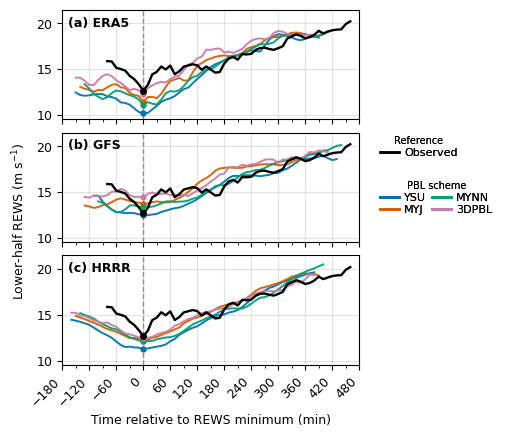

Saved: timeseries_rews_lower_half_lag_aligned_vert54/E05/lower_half_rews_lag_aligned_complete_1x3_E05_vert54.pdf
Saved: timeseries_rews_lower_half_lag_aligned_vert54/E05/lower_half_rews_lag_aligned_complete_1x3_E05_vert54.png
E06 complete relative-time limits: -180 to 360 min


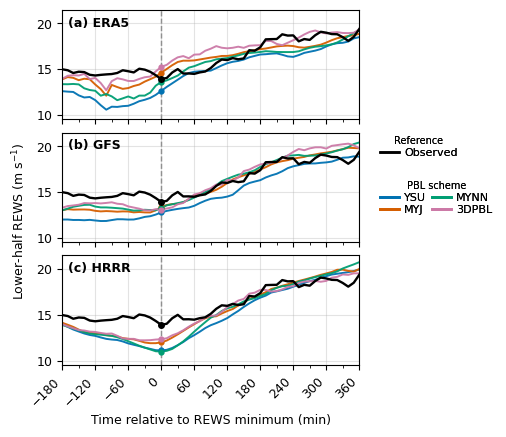

Saved: timeseries_rews_lower_half_lag_aligned_vert54/E06/lower_half_rews_lag_aligned_complete_1x3_E06_vert54.pdf
Saved: timeseries_rews_lower_half_lag_aligned_vert54/E06/lower_half_rews_lag_aligned_complete_1x3_E06_vert54.png

Complete lag-aligned lower-half REWS figures finished.
Outputs saved under: timeseries_rews_lower_half_lag_aligned_vert54/E05 and timeseries_rews_lower_half_lag_aligned_vert54/E06


In [27]:
# ====================== Block 3: plot complete lag-aligned lower-half REWS ======================

# ============================================================
# Output directory
# KEEP UNCHANGED
# ============================================================

OUT_ROOT_ALIGNED = "timeseries_rews_lower_half_lag_aligned_vert54"

# Same natural size as the other vertically stacked
# time-series figures
FIGSIZE_3PAN = (5.5, 4.5)


def ensure_aligned_outdir(loc):
    """
    Create an output directory for each location.
    """

    outdir = os.path.join(
        OUT_ROOT_ALIGNED,
        loc
    )

    os.makedirs(
        outdir,
        exist_ok=True
    )

    return outdir


# ============================================================
# Calculate complete relative-time limits
# ============================================================

def compute_full_tau_limits(
    loc,
    alignment_results,
    major_interval=60
):
    """
    Calculate common relative-time limits using the complete
    observed and modeled REWS records.

    No REWS data are removed.

    Limits are rounded outward to the nearest
    major_interval (60 min).
    """

    tau_values = []

    # --------------------------------------------------------
    # Observed relative-time array
    # --------------------------------------------------------

    obs_tau = np.asarray(
        alignment_results[loc]["observed"]["tau"],
        dtype=float
    )

    tau_values.extend(
        obs_tau[
            np.isfinite(obs_tau)
        ]
    )

    # --------------------------------------------------------
    # Model relative-time arrays
    # --------------------------------------------------------

    for d in alignment_results[loc]["models"]:

        model_tau = np.asarray(
            d["tau"],
            dtype=float
        )

        tau_values.extend(
            model_tau[
                np.isfinite(model_tau)
            ]
        )

    tau_values = np.asarray(
        tau_values,
        dtype=float
    )

    if tau_values.size == 0:

        raise ValueError(
            f"No valid relative-time values "
            f"found for {loc}."
        )

    # Round outward to complete 60-min intervals
    tau_left = (
        np.floor(
            np.nanmin(tau_values)
            / major_interval
        )
        * major_interval
    )

    tau_right = (
        np.ceil(
            np.nanmax(tau_values)
            / major_interval
        )
        * major_interval
    )

    return (
        float(tau_left),
        float(tau_right)
    )


# ============================================================
# Right-side legends
# ============================================================

def add_aligned_rews_legend(fig):
    """
    Legends stacked vertically on the right:

      1. Reference
      2. PBL scheme

    PBL options are shown in two columns.
    """

    title_fs = 7
    label_fs = 8

    # --------------------------------------------------------
    # Reference
    # --------------------------------------------------------

    ref_handles = [
        Line2D(
            [0], [0],
            color="black",
            lw=1.8,
            linestyle="-",
            label="Observed"
        )
    ]

    # --------------------------------------------------------
    # PBL scheme
    # --------------------------------------------------------

    pbl_handles = [
        Line2D(
            [0], [0],
            color=pbl_color[p],
            lw=2.0,
            linestyle="-",
            label=(
                "3DPBL"
                if p == "3dpbl"
                else p.upper()
            )
        )
        for p in [
            "ysu",
            "myj",
            "mynn",
            "3dpbl"
        ]
    ]

    # --------------------------------------------------------
    # Reference legend
    # --------------------------------------------------------

    leg1 = fig.legend(
        handles=ref_handles,

        loc="upper left",
        bbox_to_anchor=(
            0.70,
            0.70
        ),

        frameon=False,
        ncol=1,

        title="Reference",
        title_fontsize=title_fs,
        fontsize=label_fs,

        handlelength=1.7,
        handletextpad=0.45,
        labelspacing=0.20,

        borderaxespad=0.0,
    )

    # --------------------------------------------------------
    # PBL legend
    # --------------------------------------------------------

    leg2 = fig.legend(
        handles=pbl_handles,

        loc="upper left",
        bbox_to_anchor=(
            0.70,
            0.60
        ),

        frameon=False,
        ncol=2,

        title="PBL scheme",
        title_fontsize=title_fs,
        fontsize=label_fs,

        handlelength=1.7,
        handletextpad=0.45,
        columnspacing=0.55,
        labelspacing=0.20,

        borderaxespad=0.0,
    )

    fig.add_artist(
        leg1
    )

    fig.add_artist(
        leg2
    )


# ============================================================
# Plot one forcing-dataset panel
# ============================================================

def plot_aligned_rews_panel(
    ax,
    loc,
    icbc_fixed,
    alignment_results,
    ylims,
    xlims,
    panel_txt
):
    """
    Plot complete lag-aligned lower-half REWS for one forcing dataset.

    Panels:
      ERA5 / GFS / HRRR

    Colored lines:
      YSU, MYJ, MYNN, 3DPBL

    Black line:
      observed lower-half REWS

    Relative-time coordinate:
      each individual series is referenced to its own
      selected REWS minimum.

      tau = 0 min:
          selected minimum time for that individual series.

    Complete REWS records are retained.
    """

    # --------------------------------------------------------
    # Select model runs
    # --------------------------------------------------------

    model_items = [
        d
        for d in alignment_results[loc]["models"]
        if d["icbc"] == icbc_fixed
    ]

    model_items.sort(
        key=lambda d: PBL_ORDER.get(
            d["pbl"],
            99
        )
    )

    # --------------------------------------------------------
    # Model REWS
    # --------------------------------------------------------

    for d in model_items:

        pbl = d["pbl"]

        ax.plot(
            d["tau"],
            d["rews"],

            color=pbl_color[pbl],
            linestyle="-",
            linewidth=1.4,
            alpha=0.95
        )

        # Mark selected model minimum
        ax.plot(
            0,
            d["min_value"],

            marker="o",
            markersize=3.5,

            color=pbl_color[pbl],
            linestyle="None",

            zorder=6
        )

    # --------------------------------------------------------
    # Observed REWS
    # --------------------------------------------------------

    obs = alignment_results[loc]["observed"]

    ax.plot(
        obs["tau"],
        obs["rews"],

        color="black",
        linestyle="-",
        linewidth=1.7,

        zorder=5
    )

    # Mark observed minimum
    ax.plot(
        0,
        obs["min_value"],

        marker="o",
        markersize=4.0,

        color="black",
        linestyle="None",

        zorder=7
    )

    # --------------------------------------------------------
    # Reference line at aligned minimum
    # --------------------------------------------------------

    ax.axvline(
        0,

        color="0.5",
        linestyle="--",
        linewidth=1.0,

        zorder=0
    )

    # --------------------------------------------------------
    # Limits
    # --------------------------------------------------------

    ax.set_xlim(
        xlims
    )

    ax.set_ylim(
        ylims
    )

    # --------------------------------------------------------
    # Relative-time ticks
    # --------------------------------------------------------

    major_ticks = np.arange(
        xlims[0],
        xlims[1] + 1,
        60
    )

    minor_ticks = np.arange(
        xlims[0],
        xlims[1] + 1,
        30
    )

    ax.set_xticks(
        major_ticks
    )

    ax.set_xticks(
        minor_ticks,
        minor=True
    )

    # --------------------------------------------------------
    # Grid
    # --------------------------------------------------------

    ax.grid(
        True,
        alpha=0.35,
        linewidth=0.8
    )

    # --------------------------------------------------------
    # Panel label + forcing dataset
    # --------------------------------------------------------

    ax.text(
        0.02,
        0.94,

        f"{panel_txt} "
        f"{icbc_fixed.upper()}",

        transform=ax.transAxes,

        ha="left",
        va="top",

        fontsize=9,
        fontweight="bold"
    )


# ============================================================
# 3x1 figure for one buoy
#
# Function name/output filename intentionally retain "1x3"
# so the new figure replaces the old horizontal version.
# ============================================================

def plot_aligned_rews_1x3(
    loc,
    alignment_results,
    ylims
):
    """
    Vertically stacked panels:

      (a) ERA5
      (b) GFS
      (c) HRRR

    Complete original REWS records are retained.

    The x-axis is relative to each series' own selected
    REWS minimum.
    """

    outdir = ensure_aligned_outdir(
        loc
    )

    # --------------------------------------------------------
    # Common complete relative-time range
    # --------------------------------------------------------

    full_tau_limits = compute_full_tau_limits(
        loc=loc,
        alignment_results=alignment_results,
        major_interval=60
    )

    print(
        f"{loc} complete relative-time limits: "
        f"{full_tau_limits[0]:.0f} to "
        f"{full_tau_limits[1]:.0f} min"
    )

    # ========================================================
    # FIGURE
    # ========================================================

    fig, axs = plt.subplots(
        3,
        1,

        figsize=FIGSIZE_3PAN,

        sharex=True,
        sharey=True
    )

    # Plotting panels on left;
    # legends on right.
    #
    # Slightly more bottom space than original REWS figure
    # because relative-time labels are rotated.
    fig.subplots_adjust(
        left=0.13,
        right=0.67,
        top=0.97,
        bottom=0.18,
        hspace=0.12
    )

    # --------------------------------------------------------
    # Shared y-axis label
    # --------------------------------------------------------

    fig.supylabel(
        r"Lower-half REWS (m s$^{-1}$)",
        fontsize=9,
        x=0.035
    )

    # --------------------------------------------------------
    # Panel (a): ERA5
    # --------------------------------------------------------

    plot_aligned_rews_panel(
        ax=axs[0],
        loc=loc,
        icbc_fixed="era5",
        alignment_results=alignment_results,
        ylims=ylims,
        xlims=full_tau_limits,
        panel_txt="(a)"
    )

    # --------------------------------------------------------
    # Panel (b): GFS
    # --------------------------------------------------------

    plot_aligned_rews_panel(
        ax=axs[1],
        loc=loc,
        icbc_fixed="gfs",
        alignment_results=alignment_results,
        ylims=ylims,
        xlims=full_tau_limits,
        panel_txt="(b)"
    )

    # --------------------------------------------------------
    # Panel (c): HRRR
    # --------------------------------------------------------

    plot_aligned_rews_panel(
        ax=axs[2],
        loc=loc,
        icbc_fixed="hrrr",
        alignment_results=alignment_results,
        ylims=ylims,
        xlims=full_tau_limits,
        panel_txt="(c)"
    )

    # --------------------------------------------------------
    # X-axis formatting
    # --------------------------------------------------------

    # Only bottom panel gets the x-axis title
    axs[2].set_xlabel(
        "Time relative to REWS minimum (min)"
    )

    # Rotate tick labels on bottom panel
    axs[2].tick_params(
        axis="x",
        labelrotation=45
    )

    for label in axs[2].get_xticklabels():

        label.set_horizontalalignment(
            "right"
        )

    # --------------------------------------------------------
    # Legends
    # --------------------------------------------------------

    add_aligned_rews_legend(
        fig
    )

    # ========================================================
    # OUTPUT FILENAME — KEEP UNCHANGED
    # ========================================================

    base = (
        f"lower_half_rews_lag_aligned_"
        f"complete_1x3_{loc}_vert{TARGET_VERT}"
    )

    pdf_path = os.path.join(
        outdir,
        f"{base}.pdf"
    )

    png_path = os.path.join(
        outdir,
        f"{base}.png"
    )

    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------

    fig.savefig(
        pdf_path,
        bbox_inches="tight"
    )

    fig.savefig(
        png_path,
        dpi=DPI_PNG,
        bbox_inches="tight"
    )

    plt.show()

    plt.close(
        fig
    )

    print(
        f"Saved: {pdf_path}"
    )

    print(
        f"Saved: {png_path}"
    )


# ============================================================
# RUN
# ============================================================

os.makedirs(
    OUT_ROOT_ALIGNED,
    exist_ok=True
)

# Use exactly the same y-axis limits as the
# original lower-half REWS figures
aligned_ylims = rews_ylims

print(
    f"Using original REWS y-axis limits: "
    f"{aligned_ylims}"
)

for loc in LOCATIONS:

    if loc not in alignment_results:

        print(
            f"[{loc}] "
            f"No alignment results available."
        )

        continue

    plot_aligned_rews_1x3(
        loc=loc,
        alignment_results=alignment_results,
        ylims=aligned_ylims
    )

print(
    "\nComplete lag-aligned lower-half REWS "
    "figures finished."
)

print(
    f"Outputs saved under: "
    f"{OUT_ROOT_ALIGNED}/E05 "
    f"and "
    f"{OUT_ROOT_ALIGNED}/E06"
)

In [28]:
# ====================== Block 1: Taylor helper functions using existing REWS variables ======================

# This block assumes you have already run:
#   1. lower-half REWS script
#   2. lag-alignment Blocks 1 and 2
#
# Required existing variables:
#   obs_rews
#   model_rews
#   alignment_results
#   LOCATIONS
#   ICBCS
#   PBLS
#   TARGET_VERT
#   TARGET_VERT_LABEL
#   START_TIME
#   STEP_MIN
#   make_time_index
#   pbl_color
#   icbc_marker
#   ICBC_ORDER
#   PBL_ORDER

OUT_ROOT_TAYLOR_REWS = "taylor_rews_lower_half_vert54"

os.makedirs(
    OUT_ROOT_TAYLOR_REWS,
    exist_ok=True
)


def common_finite_mask(*arrays):
    """
    Return True only where all input arrays have finite values.

    All arrays must have the same length.
    """
    if len(arrays) == 0:
        raise ValueError("No arrays were provided.")

    mask = np.ones(
        len(arrays[0]),
        dtype=bool
    )

    for arr in arrays:

        arr = np.asarray(
            arr,
            dtype=float
        )

        if len(arr) != len(mask):
            raise ValueError(
                "All arrays must have the same length "
                "before applying common_finite_mask."
            )

        mask &= np.isfinite(arr)

    return mask


def compute_taylor_stats(obs, model):
    """
    Compute Taylor-diagram statistics using observed REWS
    as the reference.

    Inputs must already be on the same time grid.

    Returns:
      std_obs   : observed standard deviation
      std_model : model standard deviation
      corr      : Pearson correlation coefficient
      crmsd     : centered RMS difference
      n         : number of valid overlapping points
    """
    obs = np.asarray(
        obs,
        dtype=float
    )

    model = np.asarray(
        model,
        dtype=float
    )

    mask = common_finite_mask(
        obs,
        model
    )

    obs_valid = obs[mask]
    model_valid = model[mask]

    n = len(obs_valid)

    if n < 2:

        return {
            "std_obs": np.nan,
            "std_model": np.nan,
            "corr": np.nan,
            "crmsd": np.nan,
            "n": n,
        }

    std_obs = np.std(
        obs_valid,
        ddof=0
    )

    std_model = np.std(
        model_valid,
        ddof=0
    )

    corr = np.corrcoef(
        obs_valid,
        model_valid
    )[0, 1]

    crmsd = np.sqrt(
        np.mean(
            (
                (model_valid - np.mean(model_valid))
                -
                (obs_valid - np.mean(obs_valid))
            ) ** 2
        )
    )

    return {
        "std_obs": std_obs,
        "std_model": std_model,
        "corr": corr,
        "crmsd": crmsd,
        "n": n,
    }


def interpolate_to_grid(x_old, y_old, x_new):
    """
    Interpolate y_old from x_old onto x_new.

    Values outside the available x_old range become NaN.
    """
    x_old = np.asarray(
        x_old,
        dtype=float
    )

    y_old = np.asarray(
        y_old,
        dtype=float
    )

    x_new = np.asarray(
        x_new,
        dtype=float
    )

    valid = (
        np.isfinite(x_old)
        & np.isfinite(y_old)
    )

    if valid.sum() < 2:

        return np.full(
            x_new.shape,
            np.nan,
            dtype=float
        )

    x_valid = x_old[valid]
    y_valid = y_old[valid]

    order = np.argsort(
        x_valid
    )

    x_valid = x_valid[order]
    y_valid = y_valid[order]

    y_new = np.interp(
        x_new,
        x_valid,
        y_valid,
        left=np.nan,
        right=np.nan
    )

    return y_new


print("Taylor helper functions loaded.")
print(f"Taylor output folder: {OUT_ROOT_TAYLOR_REWS}")
print(f"Using REWS vertical configuration: vert{TARGET_VERT} = {TARGET_VERT_LABEL}")

Taylor helper functions loaded.
Taylor output folder: taylor_rews_lower_half_vert54
Using REWS vertical configuration: vert54 = 10_194


In [29]:
# ====================== Block 2: build Taylor datasets using SAME UTC window ======================

# ============================================================
# Freeze current lower-half REWS variables
#
# This prevents accidental mixing with full-rotor REWS variables.
# Run this only after rerunning the lower-half REWS code and
# lag-alignment Blocks 1 and 2.
# ============================================================

obs_rews_lh = {}

for loc in LOCATIONS:

    if obs_rews.get(loc) is None:

        obs_rews_lh[loc] = None

    else:

        obs_rews_lh[loc] = np.asarray(
            obs_rews[loc],
            dtype=float
        ).copy()


model_rews_lh = []

for d in model_rews:

    if d["vert"] != TARGET_VERT:
        continue

    d_copy = d.copy()

    d_copy["rews"] = np.asarray(
        d["rews"],
        dtype=float
    ).copy()

    model_rews_lh.append(
        d_copy
    )


alignment_results_lh = {}

for loc in LOCATIONS:

    if loc not in alignment_results:
        continue

    obs = alignment_results[loc]["observed"]

    alignment_results_lh[loc] = {
        "observed": {
            "times": np.array(obs["times"]).copy(),
            "rews": np.asarray(obs["rews"], dtype=float).copy(),
            "tau": np.asarray(obs["tau"], dtype=float).copy(),
            "min_index": obs["min_index"],
            "min_time": obs["min_time"],
            "min_value": obs["min_value"],
        },
        "models": []
    }

    for d in alignment_results[loc]["models"]:

        if d["vert"] != TARGET_VERT:
            continue

        alignment_results_lh[loc]["models"].append({
            "path": d["path"],
            "icbc": d["icbc"],
            "pbl": d["pbl"],
            "vert": d["vert"],
            "times": np.array(d["times"]).copy(),
            "rews": np.asarray(d["rews"], dtype=float).copy(),
            "tau": np.asarray(d["tau"], dtype=float).copy(),
            "min_index": d["min_index"],
            "min_time": d["min_time"],
            "min_value": d["min_value"],
            "lag_minutes": d["lag_minutes"],
        })


print("Lower-half REWS variables frozen:")
print(f"  observed locations: {list(obs_rews_lh.keys())}")
print(f"  model series: {len(model_rews_lh)}")


# ============================================================
# Helper: sort model series consistently
# ============================================================

def sort_model_items(items):
    """
    Sort model items by ICBC and PBL scheme.
    """

    return sorted(
        items,
        key=lambda d: (
            ICBC_ORDER.get(d["icbc"], 99),
            PBL_ORDER.get(d["pbl"], 99)
        )
    )


# ============================================================
# Helper: exact mapping to a fixed grid
#
# This does not interpolate through missing data.
# It only places values onto matching 10-min timestamps.
# ============================================================

def map_to_grid_exact(x_old, y_old, x_new, scale=1000):
    """
    Map y_old onto x_new using exact coordinate matching.

    Values without a matching coordinate remain NaN.
    """

    x_old = np.asarray(
        x_old,
        dtype=float
    )

    y_old = np.asarray(
        y_old,
        dtype=float
    )

    x_new = np.asarray(
        x_new,
        dtype=float
    )

    out = np.full(
        x_new.shape,
        np.nan,
        dtype=float
    )

    lookup = {}

    for x, y in zip(x_old, y_old):

        if not np.isfinite(x):
            continue

        if not np.isfinite(y):
            continue

        key = int(
            round(x * scale)
        )

        lookup[key] = y

    for i, x in enumerate(x_new):

        key = int(
            round(x * scale)
        )

        if key in lookup:
            out[i] = lookup[key]

    return out


# ============================================================
# Helper: find lag from alignment_results_lh
# ============================================================

def get_lag_minutes_for_model(loc, icbc, pbl, path):
    """
    Get lag_minutes for a model from alignment_results_lh.

    Matching is done by path first. If path is not available,
    it falls back to ICBC + PBL.
    """

    models = alignment_results_lh[loc]["models"]

    # First try exact path match
    for d in models:

        if d["path"] == path:

            return d["lag_minutes"]

    # Fallback: ICBC + PBL
    matches = [
        d for d in models
        if d["icbc"] == icbc
        and d["pbl"] == pbl
    ]

    if len(matches) == 1:

        return matches[0]["lag_minutes"]

    raise ValueError(
        f"Could not uniquely find lag for "
        f"{loc}, {icbc}, {pbl}, path={path}"
    )


# ============================================================
# Build same-UTC-window Taylor dataset
# ============================================================

def build_same_utc_taylor_dataset_for_loc(loc):
    """
    Build unshifted and lag-corrected Taylor datasets using
    the same UTC evaluation window.

    Left Taylor panel:
      model REWS at original UTC timestamps

    Right Taylor panel:
      model REWS shifted earlier by its own lag, then compared
      against observed REWS on the same UTC timestamps

    Both panels use the same observed REWS array and same UTC
    indices.
    """

    obs = obs_rews_lh.get(loc)

    if obs is None:

        raise ValueError(
            f"No observed lower-half REWS found for {loc}."
        )

    model_items = [
        d for d in model_rews_lh
        if d["loc"] == loc
        and d["vert"] == TARGET_VERT
    ]

    model_items = sort_model_items(
        model_items
    )

    if len(model_items) == 0:

        raise ValueError(
            f"No model lower-half REWS found for {loc}."
        )

    # --------------------------------------------------------
    # Use common original data length
    # --------------------------------------------------------
    n_common = min(
        [len(obs)] + [len(d["rews"]) for d in model_items]
    )

    obs_grid = np.asarray(
        obs[:n_common],
        dtype=float
    )

    utc_times = np.array(
        make_time_index(n_common)
    )

    # Minutes from START_TIME:
    # 14:00 -> 0
    # 14:10 -> 10
    # ...
    utc_minutes = np.arange(
        n_common,
        dtype=float
    ) * STEP_MIN

    # --------------------------------------------------------
    # Build unshifted and lag-corrected arrays on the same UTC grid
    # --------------------------------------------------------
    unshifted_arrays = []
    shifted_arrays = []
    model_metadata = []

    for d in model_items:

        y_model = np.asarray(
            d["rews"][:n_common],
            dtype=float
        )

        # Unshifted model stays on original UTC grid
        y_unshifted = y_model.copy()

        # Lag in minutes:
        # lag > 0 means model minimum is later than observed.
        lag_minutes = get_lag_minutes_for_model(
            loc=loc,
            icbc=d["icbc"],
            pbl=d["pbl"],
            path=d["path"]
        )

        # Shift model timestamps earlier by lag.
        #
        # Original model time coordinate:
        #   utc_minutes
        #
        # Shifted model time coordinate:
        #   utc_minutes - lag_minutes
        #
        # Then map shifted model values back onto the original
        # UTC evaluation grid.
        shifted_time_minutes = utc_minutes - lag_minutes

        y_shifted = map_to_grid_exact(
            x_old=shifted_time_minutes,
            y_old=y_model,
            x_new=utc_minutes
        )

        unshifted_arrays.append(
            y_unshifted
        )

        shifted_arrays.append(
            y_shifted
        )

        model_metadata.append({
            "path": d["path"],
            "icbc": d["icbc"],
            "pbl": d["pbl"],
            "vert": d["vert"],
            "lag_minutes": lag_minutes,
        })

    # --------------------------------------------------------
    # Common finite mask across:
    #   observed REWS
    #   all unshifted model REWS
    #   all lag-corrected model REWS
    #
    # This enforces the same UTC window and same valid points
    # for both Taylor panels.
    # --------------------------------------------------------
    mask_all = common_finite_mask(
        obs_grid,
        *unshifted_arrays,
        *shifted_arrays
    )

    valid_indices = np.where(
        mask_all
    )[0]

    if valid_indices.size == 0:

        raise ValueError(
            f"No common valid UTC overlap found for {loc}."
        )

    start_index = valid_indices[0]
    end_index = valid_indices[-1]

    # Use all common-valid points between first and last overlap.
    # If there are internal missing values, they remain excluded
    # through mask_all.
    window_indices = np.arange(
        start_index,
        end_index + 1
    )

    final_mask = mask_all[
        window_indices
    ]

    final_indices = window_indices[
        final_mask
    ]

    obs_common = obs_grid[
        final_indices
    ]

    times_common = utc_times[
        final_indices
    ]

    utc_minutes_common = utc_minutes[
        final_indices
    ]

    # --------------------------------------------------------
    # Build model outputs and Taylor statistics
    # --------------------------------------------------------
    unshifted_models_common = []
    shifted_models_common = []

    for meta, y_unshifted, y_shifted in zip(
        model_metadata,
        unshifted_arrays,
        shifted_arrays
    ):

        y_unshifted_common = y_unshifted[
            final_indices
        ]

        y_shifted_common = y_shifted[
            final_indices
        ]

        stats_unshifted = compute_taylor_stats(
            obs_common,
            y_unshifted_common
        )

        stats_shifted = compute_taylor_stats(
            obs_common,
            y_shifted_common
        )

        unshifted_models_common.append({
            "path": meta["path"],
            "icbc": meta["icbc"],
            "pbl": meta["pbl"],
            "vert": meta["vert"],
            "lag_minutes": meta["lag_minutes"],
            "values": y_unshifted_common,
            "stats": stats_unshifted,
        })

        shifted_models_common.append({
            "path": meta["path"],
            "icbc": meta["icbc"],
            "pbl": meta["pbl"],
            "vert": meta["vert"],
            "lag_minutes": meta["lag_minutes"],
            "values": y_shifted_common,
            "stats": stats_shifted,
        })

    # --------------------------------------------------------
    # Same observed series is used for both panels
    # --------------------------------------------------------
    unshifted_data = {
        "loc": loc,
        "type": "unshifted",
        "time": times_common,
        "utc_minutes": utc_minutes_common,
        "obs": obs_common,
        "models": unshifted_models_common,
        "start_time": times_common[0],
        "end_time": times_common[-1],
        "n": len(obs_common),
    }

    shifted_data = {
        "loc": loc,
        "type": "lag_corrected",
        "time": times_common,
        "utc_minutes": utc_minutes_common,
        "obs": obs_common.copy(),
        "models": shifted_models_common,
        "start_time": times_common[0],
        "end_time": times_common[-1],
        "n": len(obs_common),
    }

    return {
        "unshifted": unshifted_data,
        "lag_corrected": shifted_data,
    }


# ============================================================
# Build datasets for all locations
# ============================================================

taylor_rews_lh = {}

for loc in LOCATIONS:

    print("\n" + "=" * 70)
    print(loc)
    print("=" * 70)

    loc_data = build_same_utc_taylor_dataset_for_loc(
        loc
    )

    taylor_rews_lh[loc] = loc_data

    unshifted_data = loc_data["unshifted"]
    shifted_data = loc_data["lag_corrected"]

    sd_unshifted_obs = np.std(
        unshifted_data["obs"],
        ddof=0
    )

    sd_shifted_obs = np.std(
        shifted_data["obs"],
        ddof=0
    )

    print("Common UTC evaluation window:")
    print(
        f"  {unshifted_data['start_time'].strftime('%H:%M')}–"
        f"{unshifted_data['end_time'].strftime('%H:%M')} UTC"
    )

    print(
        f"  N = {unshifted_data['n']}"
    )

    print("Observed reference SD:")
    print(
        f"  unshifted panel     = {sd_unshifted_obs:.4f} m s^-1"
    )
    print(
        f"  lag-corrected panel = {sd_shifted_obs:.4f} m s^-1"
    )

    if np.isclose(
        sd_unshifted_obs,
        sd_shifted_obs,
        equal_nan=True
    ):

        print("  SD check: OK, same observed reference used.")

    else:

        print("  WARNING: observed SD differs between panels.")

print("\nTaylor REWS lower-half datasets are ready.")
print("Both Taylor panels now use the same UTC observed reference window.")

Lower-half REWS variables frozen:
  observed locations: ['E05', 'E06']
  model series: 24

E05
Common UTC evaluation window:
  14:00–21:40 UTC
  N = 47
Observed reference SD:
  unshifted panel     = 1.5526 m s^-1
  lag-corrected panel = 1.5526 m s^-1
  SD check: OK, same observed reference used.

E06
Common UTC evaluation window:
  14:00–23:00 UTC
  N = 55
Observed reference SD:
  unshifted panel     = 1.8087 m s^-1
  lag-corrected panel = 1.8087 m s^-1
  SD check: OK, same observed reference used.

Taylor REWS lower-half datasets are ready.
Both Taylor panels now use the same UTC observed reference window.


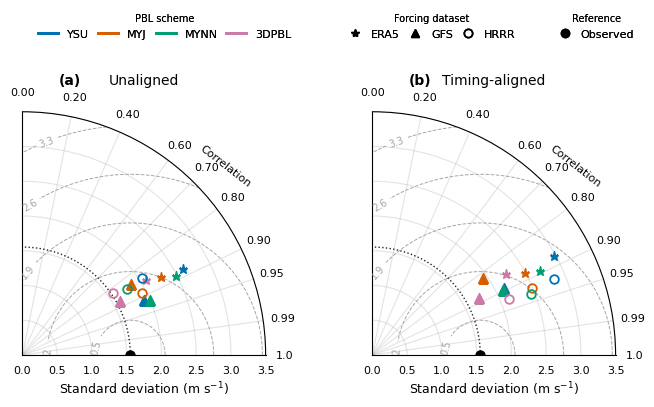

Saved: taylor_rews_lower_half_vert54/E05/taylor_lower_half_rews_unaligned_vs_timing_aligned_E05_vert54_project_style.pdf
Saved: taylor_rews_lower_half_vert54/E05/taylor_lower_half_rews_unaligned_vs_timing_aligned_E05_vert54_project_style.png
E05: Taylor rmax = 3.50 m s^-1
  Unaligned N = 47
  Timing-aligned N = 47


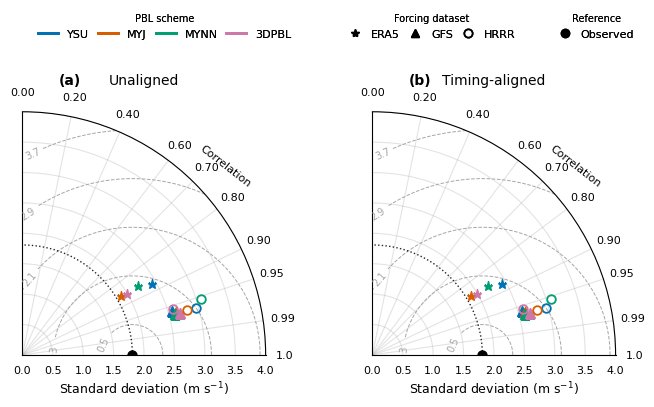

Saved: taylor_rews_lower_half_vert54/E06/taylor_lower_half_rews_unaligned_vs_timing_aligned_E06_vert54_project_style.pdf
Saved: taylor_rews_lower_half_vert54/E06/taylor_lower_half_rews_unaligned_vs_timing_aligned_E06_vert54_project_style.png
E06: Taylor rmax = 4.00 m s^-1
  Unaligned N = 55
  Timing-aligned N = 55

Taylor diagrams for unaligned and timing-aligned lower-half REWS are complete.


In [40]:
# ====================== Block 3: Taylor diagrams for lower-half REWS — project style ======================

# ============================================================
# Taylor diagram plotting helpers
# ============================================================

def compute_common_taylor_rmax(loc, pad_factor=1.15):
    """
    Compute one common radial standard-deviation limit
    for both Taylor panels of one location.
    """

    values = []

    # Keep existing dataset keys unchanged
    for case_name in ["unshifted", "lag_corrected"]:

        case_data = taylor_rews_lh[loc][case_name]

        obs_std = np.std(
            case_data["obs"],
            ddof=0
        )

        if np.isfinite(obs_std):
            values.append(obs_std)

        for d in case_data["models"]:

            std_model = d["stats"]["std_model"]

            if np.isfinite(std_model):
                values.append(std_model)

    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if values.size == 0:
        raise ValueError(
            f"No finite standard deviations found for {loc}."
        )

    rmax = np.nanmax(values) * pad_factor

    # Round upward to nearest 0.5
    rmax = np.ceil(rmax * 2.0) / 2.0

    return rmax


def setup_taylor_axes_project_style(ax, rmax, title):
    """
    Format one Taylor diagram using the same visual language
    as the previous project Taylor diagrams.
    """

    corr_ticks = np.array(
        [1.00, 0.99, 0.95, 0.90, 0.80, 0.70, 0.60, 0.40, 0.20, 0.00]
    )

    theta_ticks = np.degrees(
        np.arccos(corr_ticks)
    )

    ax.set_thetamin(0)
    ax.set_thetamax(90)

    ax.set_thetagrids(
        theta_ticks,
        labels=[
            "1.0", "0.99", "0.95", "0.90",
            "0.80", "0.70", "0.60", "0.40",
            "0.20", "0.00"
        ],
        fontsize=8
    )

    ax.set_ylim(
        0,
        rmax
    )

    ax.set_title(
        title,
        fontsize=10,
        pad=20
    )

    ax.set_xlabel(
        "Standard deviation (m s$^{-1}$)",
        fontsize=9,
        labelpad=14
    )

    ax.tick_params(
        axis="both",
        labelsize=8
    )

    ax.grid(
        True,
        alpha=0.35,
        linewidth=0.8
    )

    # Correlation label
    ax.text(
        np.deg2rad(43),
        rmax * 1.14,
        "Correlation",
        ha="center",
        va="center",
        fontsize=8,
        rotation=-38
    )


def add_crmsd_contours_project_style(ax, std_ref, rmax):
    """
    Add centered RMSE contours.
    """

    theta = np.linspace(
        0,
        np.pi / 2,
        250
    )

    radius = np.linspace(
        0,
        rmax,
        250
    )

    theta_grid, radius_grid = np.meshgrid(
        theta,
        radius
    )

    crmsd = np.sqrt(
        radius_grid**2
        + std_ref**2
        - 2.0
        * radius_grid
        * std_ref
        * np.cos(theta_grid)
    )

    max_level = np.nanmax(crmsd)

    if not np.isfinite(max_level) or max_level <= 0:
        return

    levels = np.arange(
        0.5,
        np.ceil(max_level * 2.0) / 2.0 + 0.5,
        0.5
    )

    # Avoid overcrowding
    if len(levels) > 6:
        levels = np.linspace(
            levels[0],
            levels[-1],
            6
        )

    contours = ax.contour(
        theta_grid,
        radius_grid,
        crmsd,
        levels=levels,
        colors="0.65",
        linewidths=0.7,
        linestyles="--"
    )

    ax.clabel(
        contours,
        inline=True,
        fontsize=7,
        fmt="%.1f"
    )


def plot_taylor_model_point_project_style(
    ax,
    theta,
    radius,
    icbc,
    pbl
):
    """
    Plot one model point:

      color  = PBL scheme
      marker = forcing dataset

    ERA5: star
    GFS : triangle
    HRRR: hollow circle
    """

    marker = icbc_marker.get(
        icbc,
        "o"
    )

    color = pbl_color.get(
        pbl,
        "0.5"
    )

    # HRRR: hollow circle
    if marker == "o":

        ax.plot(
            theta,
            radius,
            marker=marker,
            markersize=6.2,
            markerfacecolor="none",
            markeredgecolor=color,
            markeredgewidth=1.3,
            linestyle="None",
            zorder=5
        )

    # ERA5 star and GFS triangle
    else:

        ax.plot(
            theta,
            radius,
            marker=marker,
            markersize=6.5,
            markerfacecolor=color,
            markeredgecolor=color,
            markeredgewidth=1.0,
            linestyle="None",
            zorder=5
        )


def plot_one_taylor_panel_project_style(
    ax,
    case_data,
    rmax,
    panel_label_text,
    panel_title
):
    """
    Plot one Taylor-diagram panel.
    """

    obs = np.asarray(
        case_data["obs"],
        dtype=float
    )

    std_ref = np.std(
        obs,
        ddof=0
    )

    setup_taylor_axes_project_style(
        ax=ax,
        rmax=rmax,
        title=panel_title
    )

    add_crmsd_contours_project_style(
        ax=ax,
        std_ref=std_ref,
        rmax=rmax
    )

    # --------------------------------------------------------
    # Observed reference point
    # --------------------------------------------------------
    ax.plot(
        0,
        std_ref,
        marker="o",
        markersize=6.5,
        markerfacecolor="black",
        markeredgecolor="black",
        linestyle="None",
        zorder=10
    )

    # --------------------------------------------------------
    # Observed standard-deviation reference arc
    # --------------------------------------------------------
    theta_arc = np.linspace(
        0,
        np.pi / 2,
        250
    )

    ax.plot(
        theta_arc,
        np.full_like(theta_arc, std_ref),
        color="black",
        linestyle=":",
        linewidth=1.0,
        alpha=0.85,
        zorder=2
    )

    # --------------------------------------------------------
    # Model points
    # --------------------------------------------------------
    for d in case_data["models"]:

        stats = d["stats"]

        corr = stats["corr"]
        std_model = stats["std_model"]

        if not np.isfinite(corr) or not np.isfinite(std_model):
            continue

        # Taylor diagram displays nonnegative correlations
        corr = np.clip(
            corr,
            0.0,
            1.0
        )

        theta = np.arccos(
            corr
        )

        plot_taylor_model_point_project_style(
            ax=ax,
            theta=theta,
            radius=std_model,
            icbc=d["icbc"],
            pbl=d["pbl"]
        )

    # --------------------------------------------------------
    # Panel label
    # --------------------------------------------------------
    ax.text(
        0.15,
        1.10,
        panel_label_text,
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )


def add_taylor_legends_project_style(fig):
    """
    Add grouped legends:

      - PBL scheme
      - forcing dataset
      - observed reference
    """

    title_fs = 7
    label_fs = 8

    # --------------------------------------------------------
    # PBL color legend
    # --------------------------------------------------------
    pbl_handles = [
        Line2D(
            [0],
            [0],
            color=pbl_color[p],
            lw=2.0,
            linestyle="-",
            label=(
                "3DPBL"
                if p == "3dpbl"
                else p.upper()
            )
        )
        for p in ["ysu", "myj", "mynn", "3dpbl"]
    ]

    # --------------------------------------------------------
    # Forcing-dataset marker legend
    # --------------------------------------------------------
    forcing_handles = []

    for icbc in ["era5", "gfs", "hrrr"]:

        marker = icbc_marker[icbc]

        if marker == "o":

            handle = Line2D(
                [0],
                [0],
                marker=marker,
                color="black",
                markerfacecolor="none",
                markeredgecolor="black",
                markeredgewidth=1.2,
                linestyle="None",
                markersize=6,
                label=icbc.upper()
            )

        else:

            handle = Line2D(
                [0],
                [0],
                marker=marker,
                color="black",
                markerfacecolor="black",
                markeredgecolor="black",
                linestyle="None",
                markersize=6,
                label=icbc.upper()
            )

        forcing_handles.append(
            handle
        )

    # --------------------------------------------------------
    # Observed reference legend
    # --------------------------------------------------------
    obs_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="black",
            markerfacecolor="black",
            markeredgecolor="black",
            linestyle="None",
            markersize=6,
            label="Observed"
        )
    ]

    leg1 = fig.legend(
        handles=pbl_handles,
        loc="upper center",
        bbox_to_anchor=(0.28, 1.03),
        frameon=False,
        ncol=4,
        title="PBL scheme",
        title_fontsize=title_fs,
        fontsize=label_fs,
        handlelength=1.8,
        columnspacing=0.8,
        borderaxespad=0.0
    )

    leg2 = fig.legend(
        handles=forcing_handles,
        loc="upper center",
        bbox_to_anchor=(0.67, 1.03),
        frameon=False,
        ncol=3,
        title="Forcing dataset",
        title_fontsize=title_fs,
        fontsize=label_fs,
        handlelength=1.2,
        columnspacing=0.8,
        borderaxespad=0.0
    )

    leg3 = fig.legend(
        handles=obs_handles,
        loc="upper center",
        bbox_to_anchor=(0.91, 1.03),
        frameon=False,
        ncol=1,
        title="Reference",
        title_fontsize=title_fs,
        fontsize=label_fs,
        handlelength=1.2,
        borderaxespad=0.0
    )

    fig.add_artist(leg1)
    fig.add_artist(leg2)
    fig.add_artist(leg3)


# ============================================================
# Main plotting function
# ============================================================

def plot_taylor_rews_for_loc_project_style(loc):
    """
    Make one Taylor figure for one buoy.

    Left:
      unaligned lower-half REWS

    Right:
      timing-aligned lower-half REWS

    Existing data keys remain:
      "unshifted"
      "lag_corrected"
    """

    outdir = os.path.join(
        OUT_ROOT_TAYLOR_REWS,
        loc
    )

    os.makedirs(
        outdir,
        exist_ok=True
    )

    rmax = compute_common_taylor_rmax(
        loc
    )

    fig, axs = plt.subplots(
        1,
        2,
        figsize=(6.85, 3.8),
        subplot_kw={"projection": "polar"}
    )

    fig.subplots_adjust(
        left=0.05,
        right=0.96,
        top=0.76,
        bottom=0.12,
        wspace=0.28
    )

    # Keep existing dictionary keys unchanged
    unaligned_data = taylor_rews_lh[loc]["unshifted"]
    aligned_data = taylor_rews_lh[loc]["lag_corrected"]

    # --------------------------------------------------------
    # Panel (a): unaligned
    # --------------------------------------------------------
    plot_one_taylor_panel_project_style(
        ax=axs[0],
        case_data=unaligned_data,
        rmax=rmax,
        panel_label_text="(a)",
        panel_title="Unaligned"
    )

    # --------------------------------------------------------
    # Panel (b): timing-aligned
    # --------------------------------------------------------
    plot_one_taylor_panel_project_style(
        ax=axs[1],
        case_data=aligned_data,
        rmax=rmax,
        panel_label_text="(b)",
        panel_title="Timing-aligned"
    )

    add_taylor_legends_project_style(
        fig
    )

    # Updated manuscript terminology in filename
    base = (
        f"taylor_lower_half_rews_"
        f"unaligned_vs_timing_aligned_"
        f"{loc}_vert{TARGET_VERT}_project_style"
    )

    pdf_path = os.path.join(
        outdir,
        f"{base}.pdf"
    )

    png_path = os.path.join(
        outdir,
        f"{base}.png"
    )

    fig.savefig(
        pdf_path,
        bbox_inches="tight"
    )

    fig.savefig(
        png_path,
        dpi=DPI_PNG,
        bbox_inches="tight"
    )

    plt.show()

    plt.close(
        fig
    )

    print(f"Saved: {pdf_path}")
    print(f"Saved: {png_path}")
    print(f"{loc}: Taylor rmax = {rmax:.2f} m s^-1")
    print(f"  Unaligned N = {unaligned_data['n']}")
    print(f"  Timing-aligned N = {aligned_data['n']}")


# ============================================================
# RUN
# ============================================================

for loc in LOCATIONS:

    if loc not in taylor_rews_lh:

        print(
            f"[{loc}] No Taylor REWS dataset found."
        )

        continue

    plot_taylor_rews_for_loc_project_style(
        loc
    )


print(
    "\nTaylor diagrams for unaligned and timing-aligned "
    "lower-half REWS are complete."
)

In [31]:
# ====================== Diagnostic 1: check lag-correction direction ======================

from datetime import timedelta

for loc in LOCATIONS:

    print("\n" + "=" * 80)
    print(loc)
    print("=" * 80)

    obs_min_time = alignment_results_lh[loc]["observed"]["min_time"]

    print("Observed minimum:", obs_min_time.strftime("%H:%M UTC"))

    for d in alignment_results_lh[loc]["models"]:

        model_min_time = d["min_time"]
        lag_minutes = d["lag_minutes"]

        shifted_model_min_time = (
            model_min_time
            - timedelta(minutes=float(lag_minutes))
        )

        print(
            f"{d['icbc'].upper():<6} "
            f"{d['pbl'].upper():<6} "
            f"model min = {model_min_time.strftime('%H:%M UTC')}, "
            f"lag = {lag_minutes:>5.0f} min, "
            f"shifted min = {shifted_model_min_time.strftime('%H:%M UTC')}"
        )


E05
Observed minimum: 15:20 UTC
ERA5   YSU    model min = 16:30 UTC, lag =    70 min, shifted min = 15:20 UTC
ERA5   MYJ    model min = 16:20 UTC, lag =    60 min, shifted min = 15:20 UTC
ERA5   MYNN   model min = 16:10 UTC, lag =    50 min, shifted min = 15:20 UTC
ERA5   3DPBL  model min = 16:30 UTC, lag =    70 min, shifted min = 15:20 UTC
GFS    YSU    model min = 15:50 UTC, lag =    30 min, shifted min = 15:20 UTC
GFS    MYJ    model min = 16:10 UTC, lag =    50 min, shifted min = 15:20 UTC
GFS    MYNN   model min = 15:40 UTC, lag =    20 min, shifted min = 15:20 UTC
GFS    3DPBL  model min = 16:10 UTC, lag =    50 min, shifted min = 15:20 UTC
HRRR   YSU    model min = 16:40 UTC, lag =    80 min, shifted min = 15:20 UTC
HRRR   MYJ    model min = 16:30 UTC, lag =    70 min, shifted min = 15:20 UTC
HRRR   MYNN   model min = 16:20 UTC, lag =    60 min, shifted min = 15:20 UTC
HRRR   3DPBL  model min = 16:40 UTC, lag =    80 min, shifted min = 15:20 UTC

E06
Observed minimum: 17:00 UT

In [32]:
# ====================== Diagnostic 2: compare unshifted vs lag-corrected metrics ======================

def basic_error_metrics(obs, model):
    obs = np.asarray(obs, dtype=float)
    model = np.asarray(model, dtype=float)

    mask = common_finite_mask(obs, model)

    obs = obs[mask]
    model = model[mask]

    if len(obs) < 2:
        return {
            "n": len(obs),
            "bias": np.nan,
            "mae": np.nan,
            "rmse": np.nan,
            "corr": np.nan,
            "std_obs": np.nan,
            "std_model": np.nan,
            "crmsd": np.nan,
        }

    bias = np.mean(model - obs)
    mae = np.mean(np.abs(model - obs))
    rmse = np.sqrt(np.mean((model - obs) ** 2))
    corr = np.corrcoef(obs, model)[0, 1]

    std_obs = np.std(obs, ddof=0)
    std_model = np.std(model, ddof=0)

    crmsd = np.sqrt(
        np.mean(
            (
                (model - np.mean(model))
                -
                (obs - np.mean(obs))
            ) ** 2
        )
    )

    return {
        "n": len(obs),
        "bias": bias,
        "mae": mae,
        "rmse": rmse,
        "corr": corr,
        "std_obs": std_obs,
        "std_model": std_model,
        "crmsd": crmsd,
    }


for loc in LOCATIONS:

    print("\n" + "=" * 100)
    print(loc)
    print("=" * 100)

    unshifted = taylor_rews_lh[loc]["unshifted"]
    shifted = taylor_rews_lh[loc]["lag_corrected"]

    obs_u = unshifted["obs"]
    obs_s = shifted["obs"]

    print(
        "Observed SD check:",
        f"unshifted = {np.std(obs_u, ddof=0):.3f},",
        f"lag-corrected = {np.std(obs_s, ddof=0):.3f}"
    )

    print(
        f"{'ICBC':<6} {'PBL':<6} "
        f"{'RMSE_u':>8} {'RMSE_s':>8} "
        f"{'MAE_u':>8} {'MAE_s':>8} "
        f"{'Corr_u':>8} {'Corr_s':>8} "
        f"{'STD_u':>8} {'STD_s':>8} "
        f"{'cRMSD_u':>9} {'cRMSD_s':>9}"
    )

    print("-" * 100)

    for du, ds in zip(unshifted["models"], shifted["models"]):

        mu = basic_error_metrics(
            obs_u,
            du["values"]
        )

        ms = basic_error_metrics(
            obs_s,
            ds["values"]
        )

        print(
            f"{du['icbc'].upper():<6} "
            f"{du['pbl'].upper():<6} "
            f"{mu['rmse']:8.3f} "
            f"{ms['rmse']:8.3f} "
            f"{mu['mae']:8.3f} "
            f"{ms['mae']:8.3f} "
            f"{mu['corr']:8.3f} "
            f"{ms['corr']:8.3f} "
            f"{mu['std_model']:8.3f} "
            f"{ms['std_model']:8.3f} "
            f"{mu['crmsd']:9.3f} "
            f"{ms['crmsd']:9.3f}"
        )


E05
Observed SD check: unshifted = 1.553, lag-corrected = 1.553
ICBC   PBL      RMSE_u   RMSE_s    MAE_u    MAE_s   Corr_u   Corr_s    STD_u    STD_s   cRMSD_u   cRMSD_s
----------------------------------------------------------------------------------------------------
ERA5   YSU       2.596    2.163    2.177    1.646    0.883    0.878    2.625    2.978     1.451     1.777
ERA5   MYJ       1.672    1.399    1.218    1.147    0.871    0.880    2.289    2.490     1.208     1.345
ERA5   MYNN      2.022    1.718    1.588    1.292    0.889    0.894    2.478    2.694     1.307     1.479
ERA5   3DPBL     1.232    1.238    0.980    1.041    0.854    0.857    2.085    2.253     1.107     1.222
GFS    YSU       1.319    1.276    1.062    0.988    0.911    0.890    1.922    2.120     0.817     1.023
GFS    MYJ       1.064    1.146    0.910    0.935    0.836    0.821    1.874    1.934     1.028     1.105
GFS    MYNN      0.992    1.037    0.751    0.797    0.918    0.896    1.993    2.100     0.

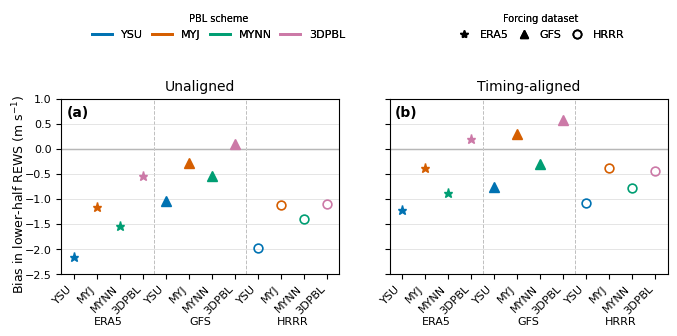

Saved: plots_mean_bias_rews_lower_half_vert54_same_utc/E05/mean_bias_lower_half_rews_unaligned_vs_timing_aligned_E05_vert54.pdf
Saved: plots_mean_bias_rews_lower_half_vert54_same_utc/E05/mean_bias_lower_half_rews_unaligned_vs_timing_aligned_E05_vert54.png


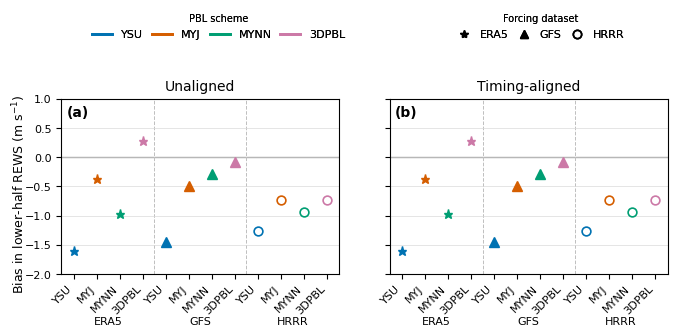

Saved: plots_mean_bias_rews_lower_half_vert54_same_utc/E06/mean_bias_lower_half_rews_unaligned_vs_timing_aligned_E06_vert54.pdf
Saved: plots_mean_bias_rews_lower_half_vert54_same_utc/E06/mean_bias_lower_half_rews_unaligned_vs_timing_aligned_E06_vert54.png

Two-panel lower-half REWS bias figures are complete.


In [33]:
# ====================== Two-panel REWS bias: unaligned vs timing-aligned ======================

import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

OUT_ROOT_REWS_BIAS = "plots_mean_bias_rews_lower_half_vert54_same_utc"
os.makedirs(OUT_ROOT_REWS_BIAS, exist_ok=True)


# ============================================================
# Helper: configuration order
# ============================================================
def get_config_order_from_case(case_data):
    """
    Return a consistently ordered list of model dictionaries:

    ERA5 -> GFS -> HRRR

    Within each forcing dataset:
    YSU -> MYJ -> MYNN -> 3DPBL
    """
    return sorted(
        case_data["models"],
        key=lambda d: (
            ICBC_ORDER.get(d["icbc"], 99),
            PBL_ORDER.get(d["pbl"], 99)
        )
    )


# ============================================================
# Helper: mean bias
# ============================================================
def compute_mean_bias(obs, model):
    """
    Mean bias = mean(model - observation)
    """
    obs = np.asarray(obs, dtype=float)
    model = np.asarray(model, dtype=float)

    mask = np.isfinite(obs) & np.isfinite(model)

    if np.sum(mask) < 1:
        return np.nan

    return np.mean(model[mask] - obs[mask])


# ============================================================
# Helper: forcing-dataset group labels and separators
# ============================================================
def add_icbc_group_labels(ax):
    """
    Add ERA5 / GFS / HRRR labels and separators
    below the x-axis.
    """

    # Separators between forcing-dataset groups
    for xpos in [3.5, 7.5]:
        ax.axvline(
            xpos,
            color="0.75",
            linewidth=0.7,
            linestyle="--",
            zorder=0
        )

    group_centers = {
        "ERA5": 1.5,
        "GFS": 5.5,
        "HRRR": 9.5,
    }

    for label, xpos in group_centers.items():
        ax.text(
            xpos,
            -0.24,
            label,
            transform=ax.get_xaxis_transform(),
            ha="center",
            va="top",
            fontsize=8
        )


# ============================================================
# Helper: plot one panel
# ============================================================
def plot_mean_bias_panel(
    ax,
    case_data,
    panel_label,
    panel_title,
    ylims
):
    """
    Plot one panel of lower-half REWS bias values.
    """

    model_items = get_config_order_from_case(case_data)
    obs = np.asarray(case_data["obs"], dtype=float)

    x = np.arange(len(model_items))

    pbl_labels = [
        "3DPBL" if d["pbl"] == "3dpbl" else d["pbl"].upper()
        for d in model_items
    ]

    # --------------------------------------------------------
    # Zero-bias reference line
    # --------------------------------------------------------
    ax.axhline(
        0.0,
        color="0.45",
        linewidth=0.9,
        linestyle="-",
        zorder=0
    )

    # --------------------------------------------------------
    # Configurations
    # --------------------------------------------------------
    for i, d in enumerate(model_items):

        model = np.asarray(
            d["values"],
            dtype=float
        )

        bias_val = compute_mean_bias(
            obs,
            model
        )

        marker = icbc_marker[d["icbc"]]
        color = pbl_color[d["pbl"]]

        # HRRR = open circle
        if marker == "o":

            ax.plot(
                x[i],
                bias_val,

                marker=marker,
                markersize=6.3,

                linestyle="None",

                markerfacecolor="none",
                markeredgecolor=color,
                markeredgewidth=1.2,

                zorder=4
            )

        else:

            ax.plot(
                x[i],
                bias_val,

                marker=marker,
                markersize=6.5,

                linestyle="None",

                markerfacecolor=color,
                markeredgecolor=color,
                markeredgewidth=1.0,

                zorder=4
            )

    # --------------------------------------------------------
    # Panel formatting
    # --------------------------------------------------------
    ax.set_title(
        panel_title,
        fontsize=10
    )

    ax.set_ylim(
        ylims
    )

    ax.set_xticks(
        x
    )

    ax.set_xticklabels(
        pbl_labels,
        rotation=45,
        ha="right",
        fontsize=8
    )

    add_icbc_group_labels(
        ax
    )

    ax.grid(
        True,
        axis="y",
        color="0.85",
        linewidth=0.6,
        linestyle="-",
        alpha=0.8
    )

    ax.tick_params(
        axis="y",
        labelsize=8
    )

    # Panel label
    ax.text(
        0.02,
        0.96,
        panel_label,

        transform=ax.transAxes,

        ha="left",
        va="top",

        fontsize=10,
        fontweight="bold"
    )


# ============================================================
# Helper: common y-limits across both panels
# ============================================================
def compute_bias_ylims_for_loc(
    loc,
    pad_fraction=0.12
):
    """
    Compute one common y-axis range for the unaligned and
    timing-aligned bias panels of one buoy.

    Note:
    The existing dataset keys remain:
        "unshifted"
        "lag_corrected"
    """

    values = []

    for case_name in [
        "unshifted",
        "lag_corrected"
    ]:

        case_data = taylor_rews_lh[loc][case_name]

        obs = np.asarray(
            case_data["obs"],
            dtype=float
        )

        for d in case_data["models"]:

            model = np.asarray(
                d["values"],
                dtype=float
            )

            values.append(
                compute_mean_bias(
                    obs,
                    model
                )
            )

    values = np.asarray(
        values,
        dtype=float
    )

    values = values[
        np.isfinite(values)
    ]

    if len(values) == 0:
        return (-1.0, 1.0)

    ymin = min(
        0.0,
        np.min(values)
    )

    ymax = max(
        0.0,
        np.max(values)
    )

    if np.isclose(
        ymin,
        ymax
    ):
        pad = 0.5

    else:
        pad = pad_fraction * (
            ymax - ymin
        )

    ymin -= pad
    ymax += pad

    # Round outward to 0.5 m s^-1
    ymin = np.floor(
        ymin * 2
    ) / 2

    ymax = np.ceil(
        ymax * 2
    ) / 2

    return (
        ymin,
        ymax
    )


# ============================================================
# Legends
# ============================================================
def add_rews_bias_legends(fig):
    """
    Add figure-level legends for:

      - PBL scheme
      - Forcing dataset
    """

    # --------------------------------------------------------
    # PBL colors
    # --------------------------------------------------------
    pbl_handles = [
        Line2D(
            [0], [0],
            color=pbl_color[p],
            lw=2.0,
            linestyle="-",
            label=(
                "3DPBL"
                if p == "3dpbl"
                else p.upper()
            )
        )
        for p in [
            "ysu",
            "myj",
            "mynn",
            "3dpbl"
        ]
    ]

    # --------------------------------------------------------
    # Forcing-dataset markers
    # --------------------------------------------------------
    forcing_handles = []

    for icbc in [
        "era5",
        "gfs",
        "hrrr"
    ]:

        marker = icbc_marker[icbc]

        if marker == "o":

            handle = Line2D(
                [0], [0],

                marker=marker,
                color="black",

                markerfacecolor="none",
                markeredgecolor="black",
                markeredgewidth=1.2,

                linestyle="None",
                markersize=6,

                label=icbc.upper()
            )

        else:

            handle = Line2D(
                [0], [0],

                marker=marker,
                color="black",

                markerfacecolor="black",
                markeredgecolor="black",

                linestyle="None",
                markersize=6,

                label=icbc.upper()
            )

        forcing_handles.append(
            handle
        )

    # --------------------------------------------------------
    # PBL legend
    # --------------------------------------------------------
    leg1 = fig.legend(
        handles=pbl_handles,

        loc="upper center",
        bbox_to_anchor=(0.33, 1.02),

        frameon=False,
        ncol=4,

        title="PBL scheme",
        title_fontsize=7,
        fontsize=8,

        handlelength=1.8,
        columnspacing=0.8
    )

    # --------------------------------------------------------
    # Forcing legend
    # --------------------------------------------------------
    leg2 = fig.legend(
        handles=forcing_handles,

        loc="upper center",
        bbox_to_anchor=(0.80, 1.02),

        frameon=False,
        ncol=3,

        title="Forcing dataset",
        title_fontsize=7,
        fontsize=8,

        handlelength=1.2,
        columnspacing=0.8
    )

    fig.add_artist(
        leg1
    )

    fig.add_artist(
        leg2
    )


# ============================================================
# Main plotting function
# ============================================================
def plot_rews_mean_bias_two_panel(loc):
    """
    Make one two-panel lower-half REWS bias figure:

      (a) Unaligned
      (b) Timing-aligned
    """

    ylims = compute_bias_ylims_for_loc(
        loc
    )

    fig, axs = plt.subplots(
        1,
        2,

        figsize=(6.85, 3.65),

        sharey=True
    )

    fig.subplots_adjust(
        left=0.10,
        right=0.985,
        top=0.76,
        bottom=0.28,
        wspace=0.18
    )

    # --------------------------------------------------------
    # Shared y-axis label
    # --------------------------------------------------------
    fig.supylabel(
        r"Bias in lower-half REWS (m s$^{-1}$)",
        fontsize=9,
        x=0.025
    )

    # --------------------------------------------------------
    # Panel (a): unaligned
    # --------------------------------------------------------
    plot_mean_bias_panel(
        ax=axs[0],
        case_data=taylor_rews_lh[loc]["unshifted"],
        panel_label="(a)",
        panel_title="Unaligned",
        ylims=ylims
    )

    # --------------------------------------------------------
    # Panel (b): timing-aligned
    #
    # Existing dictionary key is retained.
    # --------------------------------------------------------
    plot_mean_bias_panel(
        ax=axs[1],
        case_data=taylor_rews_lh[loc]["lag_corrected"],
        panel_label="(b)",
        panel_title="Timing-aligned",
        ylims=ylims
    )

    # --------------------------------------------------------
    # Legends
    # --------------------------------------------------------
    add_rews_bias_legends(
        fig
    )

    # ========================================================
    # OUTPUT
    #
    # Keep the existing output directory.
    # Filename terminology updated for the manuscript.
    # ========================================================

    base = (
        f"mean_bias_lower_half_rews_"
        f"unaligned_vs_timing_aligned_"
        f"{loc}_vert{TARGET_VERT}"
    )

    outdir = os.path.join(
        OUT_ROOT_REWS_BIAS,
        loc
    )

    os.makedirs(
        outdir,
        exist_ok=True
    )

    pdf_path = os.path.join(
        outdir,
        f"{base}.pdf"
    )

    png_path = os.path.join(
        outdir,
        f"{base}.png"
    )

    fig.savefig(
        pdf_path,
        bbox_inches="tight"
    )

    fig.savefig(
        png_path,
        dpi=DPI_PNG,
        bbox_inches="tight"
    )

    plt.show()

    plt.close(
        fig
    )

    print(
        f"Saved: {pdf_path}"
    )

    print(
        f"Saved: {png_path}"
    )


# ============================================================
# RUN
# ============================================================

for loc in LOCATIONS:

    if loc not in taylor_rews_lh:

        print(
            f"[{loc}] "
            f"No REWS Taylor dataset found."
        )

        continue

    plot_rews_mean_bias_two_panel(
        loc
    )


print(
    "\nTwo-panel lower-half REWS bias "
    "figures are complete."
)

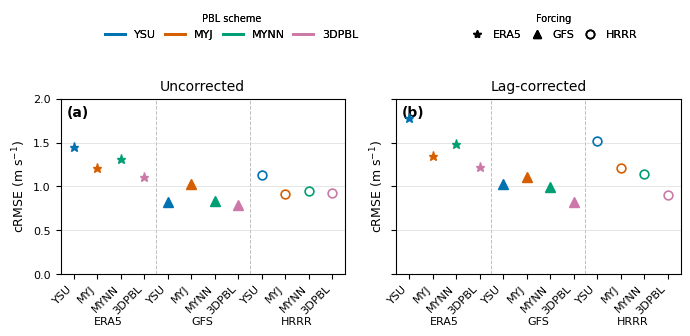

Saved: plots_crmse_rews_lower_half_vert54_same_utc/E05/crmse_lower_half_rews_uncorrected_vs_corrected_E05_vert54.pdf
Saved: plots_crmse_rews_lower_half_vert54_same_utc/E05/crmse_lower_half_rews_uncorrected_vs_corrected_E05_vert54.png


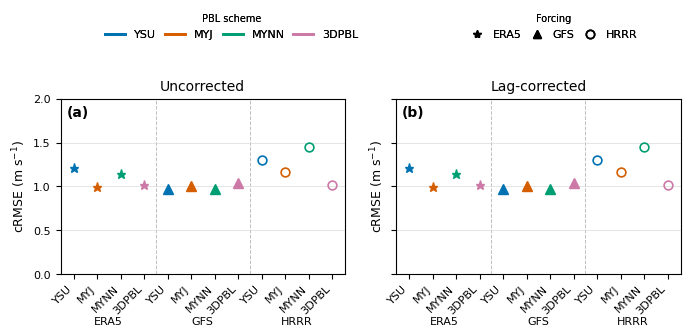

Saved: plots_crmse_rews_lower_half_vert54_same_utc/E06/crmse_lower_half_rews_uncorrected_vs_corrected_E06_vert54.pdf
Saved: plots_crmse_rews_lower_half_vert54_same_utc/E06/crmse_lower_half_rews_uncorrected_vs_corrected_E06_vert54.png

Two-panel cRMSE REWS figures are complete.


In [34]:
# ====================== Two-panel cRMSE plot: uncorrected vs corrected REWS ======================

import os
import numpy as np
import matplotlib.pyplot as plt

OUT_ROOT_REWS_CRMSE = "plots_crmse_rews_lower_half_vert54_same_utc"
os.makedirs(OUT_ROOT_REWS_CRMSE, exist_ok=True)


# ============================================================
# Helper: centered RMSE
# ============================================================
def compute_crmse(obs, model):
    """
    Centered RMSE:
    sqrt( mean( [ (model - mean(model)) - (obs - mean(obs)) ]^2 ) )
    """
    obs = np.asarray(obs, dtype=float)
    model = np.asarray(model, dtype=float)

    mask = np.isfinite(obs) & np.isfinite(model)

    if np.sum(mask) < 2:
        return np.nan

    obs_valid = obs[mask]
    model_valid = model[mask]

    obs_anom = obs_valid - np.mean(obs_valid)
    model_anom = model_valid - np.mean(model_valid)

    crmse = np.sqrt(
        np.mean((model_anom - obs_anom) ** 2)
    )

    return crmse


# ============================================================
# Helper: common y-limits across both panels
# ============================================================
def compute_crmse_ylims_for_loc(loc, pad_fraction=0.12):
    """
    Compute one common y-axis range for the unshifted and
    lag-corrected cRMSE panels of one buoy.
    """

    values = []

    for case_name in ["unshifted", "lag_corrected"]:
        case_data = taylor_rews_lh[loc][case_name]
        obs = np.asarray(case_data["obs"], dtype=float)

        for d in case_data["models"]:
            model = np.asarray(d["values"], dtype=float)
            values.append(compute_crmse(obs, model))

    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return (0.0, 1.0)

    ymin = 0.0
    ymax = np.max(values)

    pad = 0.5 if np.isclose(ymax, 0.0) else pad_fraction * ymax
    ymax = ymax + pad

    # round up slightly for cleaner axes
    ymax = np.ceil(ymax * 2) / 2

    return (ymin, ymax)


# ============================================================
# Helper: plot one panel
# ============================================================
def plot_crmse_panel(ax, case_data, panel_label, panel_title, ylims):
    """
    Plot one panel of cRMSE values.
    """

    model_items = get_config_order_from_case(case_data)
    obs = np.asarray(case_data["obs"], dtype=float)

    x = np.arange(len(model_items))
    pbl_labels = [d["pbl"].upper() for d in model_items]

    for i, d in enumerate(model_items):

        model = np.asarray(d["values"], dtype=float)
        crmse_val = compute_crmse(obs, model)

        marker = icbc_marker[d["icbc"]]
        color = pbl_color[d["pbl"]]

        if marker == "o":
            ax.plot(
                x[i],
                crmse_val,
                marker=marker,
                markersize=6.3,
                linestyle="None",
                markerfacecolor="none",
                markeredgecolor=color,
                markeredgewidth=1.2,
                zorder=4
            )
        else:
            ax.plot(
                x[i],
                crmse_val,
                marker=marker,
                markersize=6.5,
                linestyle="None",
                markerfacecolor=color,
                markeredgecolor=color,
                markeredgewidth=1.0,
                zorder=4
            )

    ax.set_title(panel_title, fontsize=10)
    ax.set_ylabel("cRMSE (m s$^{-1}$)", fontsize=9)
    ax.set_ylim(ylims)

    ax.set_xticks(x)
    ax.set_xticklabels(
        pbl_labels,
        rotation=45,
        ha="right",
        fontsize=8
    )

    add_icbc_group_labels(ax)

    ax.grid(
        True,
        axis="y",
        color="0.85",
        linewidth=0.6,
        linestyle="-",
        alpha=0.8
    )

    ax.tick_params(axis="y", labelsize=8)

    ax.text(
        0.02,
        0.96,
        panel_label,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        fontweight="bold"
    )


# ============================================================
# Main plotting function
# ============================================================
def plot_rews_crmse_two_panel(loc):
    """
    Make one 2-panel cRMSE figure for one buoy:
      (a) uncorrected
      (b) lag-corrected
    """

    ylims = compute_crmse_ylims_for_loc(loc)

    fig, axs = plt.subplots(
        1,
        2,
        figsize=(6.85, 3.65),
        sharey=True
    )

    fig.subplots_adjust(
        left=0.08,
        right=0.985,
        top=0.76,
        bottom=0.28,
        wspace=0.18
    )

    plot_crmse_panel(
        ax=axs[0],
        case_data=taylor_rews_lh[loc]["unshifted"],
        panel_label="(a)",
        panel_title="Uncorrected",
        ylims=ylims
    )

    plot_crmse_panel(
        ax=axs[1],
        case_data=taylor_rews_lh[loc]["lag_corrected"],
        panel_label="(b)",
        panel_title="Lag-corrected",
        ylims=ylims
    )

    add_rews_bias_legends(fig)

    base = f"crmse_lower_half_rews_uncorrected_vs_corrected_{loc}_vert{TARGET_VERT}"

    outdir = os.path.join(OUT_ROOT_REWS_CRMSE, loc)
    os.makedirs(outdir, exist_ok=True)

    pdf_path = os.path.join(outdir, f"{base}.pdf")
    png_path = os.path.join(outdir, f"{base}.png")

    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, dpi=DPI_PNG, bbox_inches="tight")

    plt.show()
    plt.close(fig)

    print(f"Saved: {pdf_path}")
    print(f"Saved: {png_path}")


# ============================================================
# RUN
# ============================================================

for loc in LOCATIONS:

    if loc not in taylor_rews_lh:
        print(f"[{loc}] No REWS Taylor dataset found.")
        continue

    plot_rews_crmse_two_panel(loc)

print("\nTwo-panel cRMSE REWS figures are complete.")

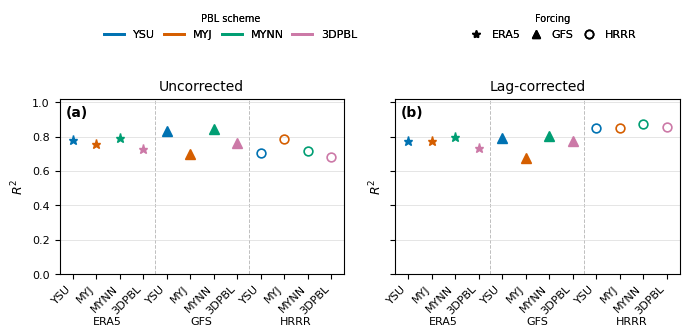

Saved: plots_r2_rews_lower_half_vert54_same_utc/E05/r2_lower_half_rews_uncorrected_vs_corrected_E05_vert54.pdf
Saved: plots_r2_rews_lower_half_vert54_same_utc/E05/r2_lower_half_rews_uncorrected_vs_corrected_E05_vert54.png


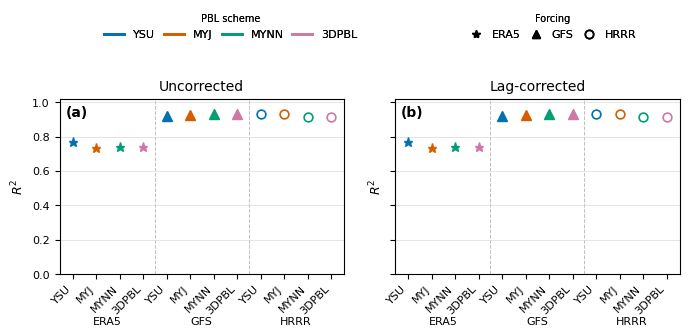

Saved: plots_r2_rews_lower_half_vert54_same_utc/E06/r2_lower_half_rews_uncorrected_vs_corrected_E06_vert54.pdf
Saved: plots_r2_rews_lower_half_vert54_same_utc/E06/r2_lower_half_rews_uncorrected_vs_corrected_E06_vert54.png

Two-panel R2 REWS figures are complete.


In [35]:
# ====================== Two-panel R2 plot: uncorrected vs corrected REWS ======================

import os
import numpy as np
import matplotlib.pyplot as plt

OUT_ROOT_REWS_R2 = "plots_r2_rews_lower_half_vert54_same_utc"
os.makedirs(OUT_ROOT_REWS_R2, exist_ok=True)


# ============================================================
# Helper: R2
# ============================================================
def compute_r2(obs, model):
    """
    R2 = Pearson correlation squared.
    """

    obs = np.asarray(obs, dtype=float)
    model = np.asarray(model, dtype=float)

    mask = np.isfinite(obs) & np.isfinite(model)

    if np.sum(mask) < 2:
        return np.nan

    r = np.corrcoef(
        obs[mask],
        model[mask]
    )[0, 1]

    return r**2


# ============================================================
# Helper: plot one R2 panel
# ============================================================
def plot_r2_panel(ax, case_data, panel_label, panel_title):
    """
    Plot one panel of R2 values.
    """

    model_items = get_config_order_from_case(case_data)
    obs = np.asarray(case_data["obs"], dtype=float)

    x = np.arange(len(model_items))
    pbl_labels = [d["pbl"].upper() for d in model_items]

    for i, d in enumerate(model_items):

        model = np.asarray(d["values"], dtype=float)
        r2_val = compute_r2(obs, model)

        marker = icbc_marker[d["icbc"]]
        color = pbl_color[d["pbl"]]

        if marker == "o":

            ax.plot(
                x[i],
                r2_val,
                marker=marker,
                markersize=6.3,
                linestyle="None",
                markerfacecolor="none",
                markeredgecolor=color,
                markeredgewidth=1.2,
                zorder=4
            )

        else:

            ax.plot(
                x[i],
                r2_val,
                marker=marker,
                markersize=6.5,
                linestyle="None",
                markerfacecolor=color,
                markeredgecolor=color,
                markeredgewidth=1.0,
                zorder=4
            )

    ax.set_title(panel_title, fontsize=10)
    ax.set_ylabel("$R^2$", fontsize=9)

    ax.set_ylim(
        0.0,
        1.02
    )

    ax.set_xticks(x)
    ax.set_xticklabels(
        pbl_labels,
        rotation=45,
        ha="right",
        fontsize=8
    )

    add_icbc_group_labels(ax)

    ax.grid(
        True,
        axis="y",
        color="0.85",
        linewidth=0.6,
        linestyle="-",
        alpha=0.8
    )

    ax.tick_params(axis="y", labelsize=8)

    ax.text(
        0.02,
        0.96,
        panel_label,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        fontweight="bold"
    )


# ============================================================
# Main plotting function
# ============================================================
def plot_rews_r2_two_panel(loc):
    """
    Make one 2-panel R2 figure for one buoy:
      (a) uncorrected
      (b) lag-corrected
    """

    fig, axs = plt.subplots(
        1,
        2,
        figsize=(6.85, 3.65),
        sharey=True
    )

    fig.subplots_adjust(
        left=0.08,
        right=0.985,
        top=0.76,
        bottom=0.28,
        wspace=0.18
    )

    plot_r2_panel(
        ax=axs[0],
        case_data=taylor_rews_lh[loc]["unshifted"],
        panel_label="(a)",
        panel_title="Uncorrected"
    )

    plot_r2_panel(
        ax=axs[1],
        case_data=taylor_rews_lh[loc]["lag_corrected"],
        panel_label="(b)",
        panel_title="Lag-corrected"
    )

    add_rews_bias_legends(fig)

    base = f"r2_lower_half_rews_uncorrected_vs_corrected_{loc}_vert{TARGET_VERT}"

    outdir = os.path.join(
        OUT_ROOT_REWS_R2,
        loc
    )

    os.makedirs(
        outdir,
        exist_ok=True
    )

    pdf_path = os.path.join(
        outdir,
        f"{base}.pdf"
    )

    png_path = os.path.join(
        outdir,
        f"{base}.png"
    )

    fig.savefig(
        pdf_path,
        bbox_inches="tight"
    )

    fig.savefig(
        png_path,
        dpi=DPI_PNG,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

    print(f"Saved: {pdf_path}")
    print(f"Saved: {png_path}")


# ============================================================
# RUN
# ============================================================

for loc in LOCATIONS:

    if loc not in taylor_rews_lh:
        print(f"[{loc}] No REWS Taylor dataset found.")
        continue

    plot_rews_r2_two_panel(loc)

print("\nTwo-panel R2 REWS figures are complete.")

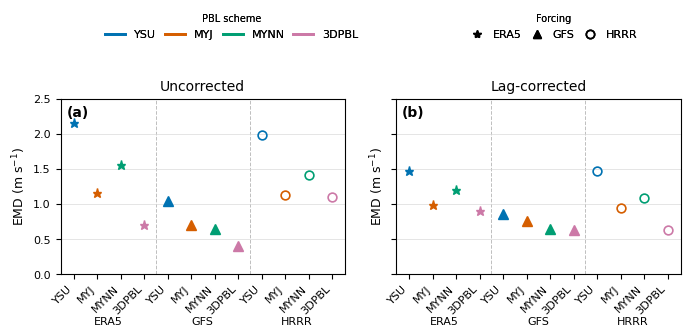

Saved: plots_emd_rews_lower_half_vert54_same_utc/E05/emd_lower_half_rews_uncorrected_vs_corrected_E05_vert54.pdf
Saved: plots_emd_rews_lower_half_vert54_same_utc/E05/emd_lower_half_rews_uncorrected_vs_corrected_E05_vert54.png


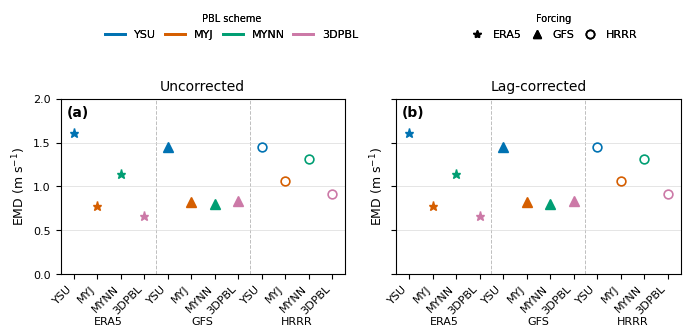

Saved: plots_emd_rews_lower_half_vert54_same_utc/E06/emd_lower_half_rews_uncorrected_vs_corrected_E06_vert54.pdf
Saved: plots_emd_rews_lower_half_vert54_same_utc/E06/emd_lower_half_rews_uncorrected_vs_corrected_E06_vert54.png

Two-panel EMD REWS figures are complete.


In [36]:
# ====================== Two-panel EMD plot: uncorrected vs corrected REWS ======================

import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wasserstein_distance

OUT_ROOT_REWS_EMD = "plots_emd_rews_lower_half_vert54_same_utc"
os.makedirs(OUT_ROOT_REWS_EMD, exist_ok=True)


# ============================================================
# Helper: EMD / Wasserstein distance
# ============================================================
def compute_emd(obs, model):
    """
    Earth Mover's Distance / 1-D Wasserstein distance.

    This compares the distribution of observed and modeled REWS.
    It does not evaluate timing directly.
    """

    obs = np.asarray(obs, dtype=float)
    model = np.asarray(model, dtype=float)

    mask = np.isfinite(obs) & np.isfinite(model)

    if np.sum(mask) < 2:
        return np.nan

    emd = wasserstein_distance(
        model[mask],
        obs[mask]
    )

    return emd


# ============================================================
# Helper: common y-limits across both panels
# ============================================================
def compute_emd_ylims_for_loc(loc, pad_fraction=0.12):
    """
    Compute one common y-axis range for the unshifted and
    lag-corrected EMD panels of one buoy.
    """

    values = []

    for case_name in ["unshifted", "lag_corrected"]:

        case_data = taylor_rews_lh[loc][case_name]
        obs = np.asarray(case_data["obs"], dtype=float)

        for d in case_data["models"]:

            model = np.asarray(d["values"], dtype=float)

            values.append(
                compute_emd(obs, model)
            )

    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return (0.0, 1.0)

    ymin = 0.0
    ymax = np.max(values)

    pad = 0.5 if np.isclose(ymax, 0.0) else pad_fraction * ymax
    ymax = ymax + pad

    # round upward for cleaner axes
    ymax = np.ceil(ymax * 2) / 2

    return (ymin, ymax)


# ============================================================
# Helper: plot one EMD panel
# ============================================================
def plot_emd_panel(ax, case_data, panel_label, panel_title, ylims):
    """
    Plot one panel of EMD values.
    """

    model_items = get_config_order_from_case(case_data)
    obs = np.asarray(case_data["obs"], dtype=float)

    x = np.arange(len(model_items))
    pbl_labels = [d["pbl"].upper() for d in model_items]

    for i, d in enumerate(model_items):

        model = np.asarray(d["values"], dtype=float)

        emd_val = compute_emd(
            obs,
            model
        )

        marker = icbc_marker[d["icbc"]]
        color = pbl_color[d["pbl"]]

        if marker == "o":

            ax.plot(
                x[i],
                emd_val,
                marker=marker,
                markersize=6.3,
                linestyle="None",
                markerfacecolor="none",
                markeredgecolor=color,
                markeredgewidth=1.2,
                zorder=4
            )

        else:

            ax.plot(
                x[i],
                emd_val,
                marker=marker,
                markersize=6.5,
                linestyle="None",
                markerfacecolor=color,
                markeredgecolor=color,
                markeredgewidth=1.0,
                zorder=4
            )

    ax.set_title(
        panel_title,
        fontsize=10
    )

    ax.set_ylabel(
        "EMD (m s$^{-1}$)",
        fontsize=9
    )

    ax.set_ylim(
        ylims
    )

    ax.set_xticks(
        x
    )

    ax.set_xticklabels(
        pbl_labels,
        rotation=45,
        ha="right",
        fontsize=8
    )

    add_icbc_group_labels(
        ax
    )

    ax.grid(
        True,
        axis="y",
        color="0.85",
        linewidth=0.6,
        linestyle="-",
        alpha=0.8
    )

    ax.tick_params(
        axis="y",
        labelsize=8
    )

    ax.text(
        0.02,
        0.96,
        panel_label,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        fontweight="bold"
    )


# ============================================================
# Main plotting function
# ============================================================
def plot_rews_emd_two_panel(loc):
    """
    Make one 2-panel EMD figure for one buoy:
      (a) uncorrected
      (b) lag-corrected
    """

    ylims = compute_emd_ylims_for_loc(
        loc
    )

    fig, axs = plt.subplots(
        1,
        2,
        figsize=(6.85, 3.65),
        sharey=True
    )

    fig.subplots_adjust(
        left=0.08,
        right=0.985,
        top=0.76,
        bottom=0.28,
        wspace=0.18
    )

    plot_emd_panel(
        ax=axs[0],
        case_data=taylor_rews_lh[loc]["unshifted"],
        panel_label="(a)",
        panel_title="Uncorrected",
        ylims=ylims
    )

    plot_emd_panel(
        ax=axs[1],
        case_data=taylor_rews_lh[loc]["lag_corrected"],
        panel_label="(b)",
        panel_title="Lag-corrected",
        ylims=ylims
    )

    add_rews_bias_legends(
        fig
    )

    base = f"emd_lower_half_rews_uncorrected_vs_corrected_{loc}_vert{TARGET_VERT}"

    outdir = os.path.join(
        OUT_ROOT_REWS_EMD,
        loc
    )

    os.makedirs(
        outdir,
        exist_ok=True
    )

    pdf_path = os.path.join(
        outdir,
        f"{base}.pdf"
    )

    png_path = os.path.join(
        outdir,
        f"{base}.png"
    )

    fig.savefig(
        pdf_path,
        bbox_inches="tight"
    )

    fig.savefig(
        png_path,
        dpi=DPI_PNG,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

    print(f"Saved: {pdf_path}")
    print(f"Saved: {png_path}")


# ============================================================
# RUN
# ============================================================

for loc in LOCATIONS:

    if loc not in taylor_rews_lh:
        print(f"[{loc}] No REWS Taylor dataset found.")
        continue

    plot_rews_emd_two_panel(
        loc
    )

print("\nTwo-panel EMD REWS figures are complete.")

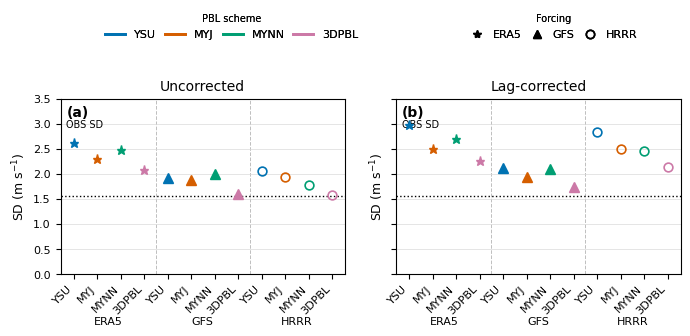

Saved: plots_sd_rews_lower_half_vert54_same_utc/E05/sd_lower_half_rews_uncorrected_vs_corrected_E05_vert54.pdf
Saved: plots_sd_rews_lower_half_vert54_same_utc/E05/sd_lower_half_rews_uncorrected_vs_corrected_E05_vert54.png


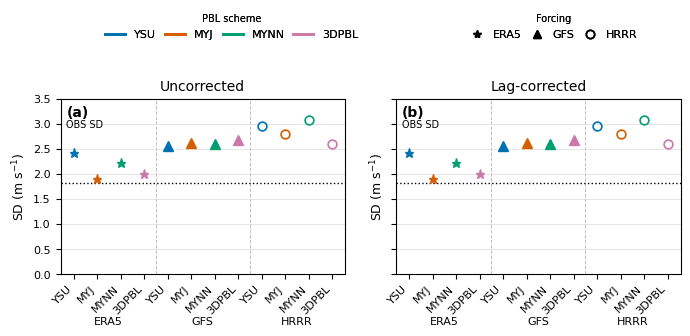

Saved: plots_sd_rews_lower_half_vert54_same_utc/E06/sd_lower_half_rews_uncorrected_vs_corrected_E06_vert54.pdf
Saved: plots_sd_rews_lower_half_vert54_same_utc/E06/sd_lower_half_rews_uncorrected_vs_corrected_E06_vert54.png

Two-panel SD REWS figures are complete.


In [37]:
# ====================== Two-panel SD plot: uncorrected vs corrected REWS ======================

import os
import numpy as np
import matplotlib.pyplot as plt

OUT_ROOT_REWS_SD = "plots_sd_rews_lower_half_vert54_same_utc"
os.makedirs(OUT_ROOT_REWS_SD, exist_ok=True)


# ============================================================
# Helper: standard deviation
# ============================================================
def compute_sd(series):
    """
    Standard deviation of one REWS time series.
    """

    series = np.asarray(series, dtype=float)

    mask = np.isfinite(series)

    if np.sum(mask) < 2:
        return np.nan

    return np.std(
        series[mask],
        ddof=0
    )


# ============================================================
# Helper: common y-limits across both panels
# ============================================================
def compute_sd_ylims_for_loc(loc, pad_fraction=0.12):
    """
    Compute one common y-axis range for the unshifted and
    lag-corrected SD panels of one buoy.
    """

    values = []

    for case_name in ["unshifted", "lag_corrected"]:

        case_data = taylor_rews_lh[loc][case_name]

        obs = np.asarray(
            case_data["obs"],
            dtype=float
        )

        values.append(
            compute_sd(obs)
        )

        for d in case_data["models"]:

            model = np.asarray(
                d["values"],
                dtype=float
            )

            values.append(
                compute_sd(model)
            )

    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return (0.0, 1.0)

    ymin = 0.0
    ymax = np.max(values)

    pad = 0.5 if np.isclose(ymax, 0.0) else pad_fraction * ymax
    ymax = ymax + pad

    ymax = np.ceil(ymax * 2) / 2

    return (ymin, ymax)


# ============================================================
# Helper: plot one SD panel
# ============================================================
def plot_sd_panel(ax, case_data, panel_label, panel_title, ylims):
    """
    Plot one panel of model SD values with observed SD reference.
    """

    model_items = get_config_order_from_case(case_data)

    obs = np.asarray(
        case_data["obs"],
        dtype=float
    )

    obs_sd = compute_sd(
        obs
    )

    x = np.arange(
        len(model_items)
    )

    pbl_labels = [
        d["pbl"].upper()
        for d in model_items
    ]

    # Observed SD reference line
    ax.axhline(
        obs_sd,
        color="black",
        linewidth=1.0,
        linestyle=":",
        zorder=1
    )

    ax.text(
        0.02,
        0.88,
        "OBS SD",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=7
    )

    for i, d in enumerate(model_items):

        model = np.asarray(
            d["values"],
            dtype=float
        )

        sd_val = compute_sd(
            model
        )

        marker = icbc_marker[d["icbc"]]
        color = pbl_color[d["pbl"]]

        if marker == "o":

            ax.plot(
                x[i],
                sd_val,
                marker=marker,
                markersize=6.3,
                linestyle="None",
                markerfacecolor="none",
                markeredgecolor=color,
                markeredgewidth=1.2,
                zorder=4
            )

        else:

            ax.plot(
                x[i],
                sd_val,
                marker=marker,
                markersize=6.5,
                linestyle="None",
                markerfacecolor=color,
                markeredgecolor=color,
                markeredgewidth=1.0,
                zorder=4
            )

    ax.set_title(
        panel_title,
        fontsize=10
    )

    ax.set_ylabel(
        "SD (m s$^{-1}$)",
        fontsize=9
    )

    ax.set_ylim(
        ylims
    )

    ax.set_xticks(
        x
    )

    ax.set_xticklabels(
        pbl_labels,
        rotation=45,
        ha="right",
        fontsize=8
    )

    add_icbc_group_labels(
        ax
    )

    ax.grid(
        True,
        axis="y",
        color="0.85",
        linewidth=0.6,
        linestyle="-",
        alpha=0.8
    )

    ax.tick_params(
        axis="y",
        labelsize=8
    )

    ax.text(
        0.02,
        0.96,
        panel_label,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        fontweight="bold"
    )


# ============================================================
# Main plotting function
# ============================================================
def plot_rews_sd_two_panel(loc):
    """
    Make one 2-panel SD figure for one buoy:
      (a) uncorrected
      (b) lag-corrected
    """

    ylims = compute_sd_ylims_for_loc(
        loc
    )

    fig, axs = plt.subplots(
        1,
        2,
        figsize=(6.85, 3.65),
        sharey=True
    )

    fig.subplots_adjust(
        left=0.08,
        right=0.985,
        top=0.76,
        bottom=0.28,
        wspace=0.18
    )

    plot_sd_panel(
        ax=axs[0],
        case_data=taylor_rews_lh[loc]["unshifted"],
        panel_label="(a)",
        panel_title="Uncorrected",
        ylims=ylims
    )

    plot_sd_panel(
        ax=axs[1],
        case_data=taylor_rews_lh[loc]["lag_corrected"],
        panel_label="(b)",
        panel_title="Lag-corrected",
        ylims=ylims
    )

    add_rews_bias_legends(
        fig
    )

    base = f"sd_lower_half_rews_uncorrected_vs_corrected_{loc}_vert{TARGET_VERT}"

    outdir = os.path.join(
        OUT_ROOT_REWS_SD,
        loc
    )

    os.makedirs(
        outdir,
        exist_ok=True
    )

    pdf_path = os.path.join(
        outdir,
        f"{base}.pdf"
    )

    png_path = os.path.join(
        outdir,
        f"{base}.png"
    )

    fig.savefig(
        pdf_path,
        bbox_inches="tight"
    )

    fig.savefig(
        png_path,
        dpi=DPI_PNG,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

    print(f"Saved: {pdf_path}")
    print(f"Saved: {png_path}")


# ============================================================
# RUN
# ============================================================

for loc in LOCATIONS:

    if loc not in taylor_rews_lh:
        print(f"[{loc}] No REWS Taylor dataset found.")
        continue

    plot_rews_sd_two_panel(
        loc
    )

print("\nTwo-panel SD REWS figures are complete.")

Observed available power E05: shape = (55,)
Observed available power E06: shape = (55,)

Model available power calculated for 24 runs.
  E05: 12 model power series
  E06: 12 model power series

Using available-power y-limits: (0.0, 101.0)

Power setup:
Air density used: 1.225 kg m^-3
Lower-half REWS layer: 30.5–138.0 m
Area used for available power: 18152.52 m^2
Full rotor area: 36305.03 m^2
Fraction of full rotor area: 50.00%
Quantity plotted: lower-half available wind power, not electrical turbine output.


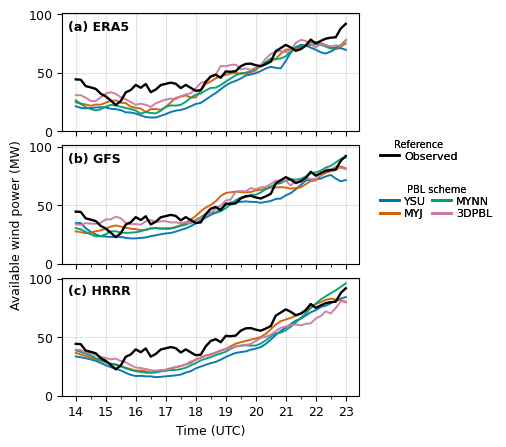

Saved: timeseries_available_power_lower_half_vert54/E05/lower_half_available_power_timeseries_1x3_E05_vert54.[pdf/png]


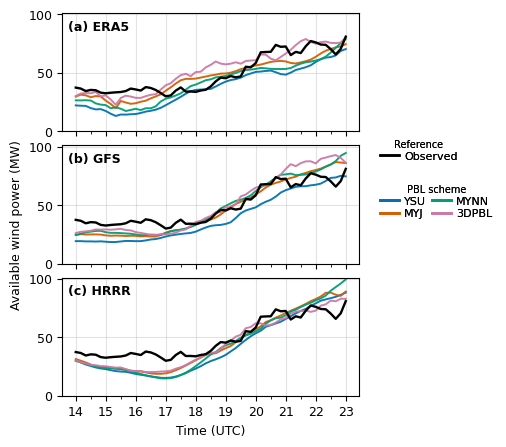

Saved: timeseries_available_power_lower_half_vert54/E06/lower_half_available_power_timeseries_1x3_E06_vert54.[pdf/png]

Done. Outputs in: timeseries_available_power_lower_half_vert54/E05 and timeseries_available_power_lower_half_vert54/E06


In [8]:
# ====================== Lower-half available power time series — 3x1 panels ======================
# Run this after the lower-half REWS script.
#
# Uses:
#   obs_rews
#   model_rews
#   A_REWS_PARTIAL
#   TARGET_VERT
#   pbl_color
#   PBL_ORDER
#   LOCATIONS
#   make_time_index
#   style_time_axis
#   DPI_PNG
#
# IMPORTANT:
# Output folder and filename are intentionally unchanged so that
# the new vertical figures replace the old horizontal figures.

import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# ============================================================
# SETTINGS
# ============================================================

RHO = 1.225  # kg m^-3

OUT_ROOT_POWER = "timeseries_available_power_lower_half_vert54"

# Same natural size as other vertically stacked time-series figures
FIGSIZE_3PAN = (5.5, 4.5)


# ============================================================
# AVAILABLE POWER CALCULATION
# ============================================================

def calculate_available_power_from_rews(
    rews,
    rho=RHO,
    area=A_REWS_PARTIAL
):
    """
    Calculate REWS-based available wind power over the same
    lower-half rotor area.

    P_avail = 0.5 * rho * A_lower_half * U_REWS^3

    Units:
      rho  = kg m^-3
      area = m^2
      U    = m s^-1
      P    = W

    Returned unit:
      MW

    This is available wind power, not turbine electrical power.
    No Cp, turbine power curve, rated-power cap, cut-in speed,
    or cut-out speed is applied.
    """

    rews = np.asarray(
        rews,
        dtype=float
    )

    power_w = (
        0.5
        * rho
        * area
        * rews**3
    )

    power_mw = (
        power_w / 1.0e6
    )

    return power_mw


# ============================================================
# BUILD AVAILABLE-POWER DATASET
# ============================================================

def build_available_power_dataset(
    obs_rews,
    model_rews
):
    """
    Convert observed and modeled lower-half REWS time series
    to lower-half available-wind-power time series.

    Returns:
      obs_power[loc] = observed lower-half available power, MW
      model_power    = list of dictionaries, one per model run
    """

    obs_power = {}
    model_power = []

    # --------------------------------------------------------
    # Observations
    # --------------------------------------------------------

    for loc in LOCATIONS:

        if obs_rews.get(loc) is None:

            obs_power[loc] = None

            print(
                f"Observed available power "
                f"{loc}: not available"
            )

        else:

            obs_power[loc] = (
                calculate_available_power_from_rews(
                    obs_rews[loc]
                )
            )

            print(
                f"Observed available power "
                f"{loc}: shape = "
                f"{obs_power[loc].shape}"
            )

    # --------------------------------------------------------
    # Models
    # --------------------------------------------------------

    for d in model_rews:

        power_mw = (
            calculate_available_power_from_rews(
                d["rews"]
            )
        )

        model_power.append({
            "path": d["path"],
            "icbc": d["icbc"],
            "pbl": d["pbl"],
            "vert": d["vert"],
            "loc": d["loc"],
            "power_mw": power_mw,
        })

    print(
        f"\nModel available power calculated "
        f"for {len(model_power)} runs."
    )

    for loc in LOCATIONS:

        n_loc = sum(
            1
            for d in model_power
            if d["loc"] == loc
        )

        print(
            f"  {loc}: "
            f"{n_loc} model power series"
        )

    return (
        obs_power,
        model_power
    )


# ============================================================
# OUTPUT DIRECTORY
# ============================================================

def ensure_power_outdir(loc):

    outdir = os.path.join(
        OUT_ROOT_POWER,
        loc
    )

    os.makedirs(
        outdir,
        exist_ok=True
    )

    return outdir


# ============================================================
# COMMON Y LIMITS
# ============================================================

def compute_power_ylims(
    obs_power,
    model_power,
    pad=1.0
):
    """
    Compute one common available-power y-axis range
    across both buoys and all model runs.
    """

    vals = []

    # Observations
    for loc in LOCATIONS:

        if obs_power.get(loc) is not None:

            vals.extend(
                np.asarray(
                    obs_power[loc]
                ).ravel()
            )

    # Models
    for d in model_power:

        vals.extend(
            np.asarray(
                d["power_mw"]
            ).ravel()
        )

    vals = np.asarray(
        vals,
        dtype=float
    )

    vals = vals[
        np.isfinite(vals)
    ]

    if vals.size == 0:

        raise ValueError(
            "No valid available-power values "
            "found for y-limit calculation."
        )

    ymin = 0.0

    ymax = np.ceil(
        vals.max() + pad
    )

    return (
        ymin,
        ymax
    )


# ============================================================
# RIGHT-SIDE LEGENDS
# ============================================================

def add_available_power_legend(fig):
    """
    Legends stacked on the right:

      1. Reference
      2. PBL scheme

    PBL scheme uses two columns.
    """

    title_fs = 7
    label_fs = 8

    # --------------------------------------------------------
    # Reference
    # --------------------------------------------------------

    ref_handles = [
        Line2D(
            [0], [0],
            color="black",
            lw=1.8,
            linestyle="-",
            label="Observed"
        )
    ]

    # --------------------------------------------------------
    # PBL scheme
    # --------------------------------------------------------

    pbl_handles = [
        Line2D(
            [0], [0],
            color=pbl_color[p],
            lw=2.0,
            linestyle="-",
            label=(
                "3DPBL"
                if p == "3dpbl"
                else p.upper()
            )
        )
        for p in [
            "ysu",
            "myj",
            "mynn",
            "3dpbl"
        ]
    ]

    # --------------------------------------------------------
    # Reference legend
    # --------------------------------------------------------

    leg1 = fig.legend(
        handles=ref_handles,

        loc="upper left",
        bbox_to_anchor=(
            0.70,
            0.70
        ),

        frameon=False,
        ncol=1,

        title="Reference",
        title_fontsize=title_fs,
        fontsize=label_fs,

        handlelength=1.7,
        handletextpad=0.45,
        labelspacing=0.20,

        borderaxespad=0.0,
    )

    # --------------------------------------------------------
    # PBL legend
    # --------------------------------------------------------

    leg2 = fig.legend(
        handles=pbl_handles,

        loc="upper left",
        bbox_to_anchor=(
            0.70,
            0.60
        ),

        frameon=False,
        ncol=2,

        title="PBL scheme",
        title_fontsize=title_fs,
        fontsize=label_fs,

        handlelength=1.7,
        handletextpad=0.45,
        columnspacing=0.55,
        labelspacing=0.20,

        borderaxespad=0.0,
    )

    fig.add_artist(
        leg1
    )

    fig.add_artist(
        leg2
    )


# ============================================================
# PLOT ONE FORCING-DATASET PANEL
# ============================================================

def plot_available_power_panel_by_icbc(
    ax,
    loc,
    icbc_fixed,
    obs_power_loc,
    model_power,
    t_ref,
    ylims,
    panel_txt
):
    """
    Plot one forcing-dataset panel.

    Panels:
      ERA5
      GFS
      HRRR

    Lines:
      PBL schemes

    Vertical configuration:
      only TARGET_VERT = vert54 / 10_194

    Black:
      observed available wind power
    """

    items = [
        d
        for d in model_power
        if (
            d["loc"] == loc
            and d["icbc"] == icbc_fixed
            and d["vert"] == TARGET_VERT
        )
    ]

    items.sort(
        key=lambda d: (
            PBL_ORDER.get(
                d["pbl"],
                99
            ),
            os.path.basename(
                os.path.dirname(
                    d["path"]
                )
            )
        )
    )

    # --------------------------------------------------------
    # Model lines
    # --------------------------------------------------------

    for d in items:

        y = d["power_mw"]
        pbl = d["pbl"]

        ax.plot(
            t_ref[:len(y)],
            y,

            color=pbl_color.get(
                pbl,
                "0.5"
            ),

            linestyle="-",
            linewidth=1.4,
            alpha=0.95
        )

    # --------------------------------------------------------
    # Observations
    # --------------------------------------------------------

    if obs_power_loc is not None:

        ax.plot(
            t_ref[
                :len(obs_power_loc)
            ],

            obs_power_loc,

            color="black",
            linestyle="-",
            linewidth=1.7,

            zorder=5
        )

    # --------------------------------------------------------
    # Axis formatting
    # --------------------------------------------------------

    ax.set_ylim(
        ylims
    )

    style_time_axis(
        ax
    )

    # Panel label and forcing dataset inside the axes
    ax.text(
        0.02,
        0.94,

        f"{panel_txt} "
        f"{icbc_fixed.upper()}",

        transform=ax.transAxes,

        ha="left",
        va="top",

        fontsize=9,
        fontweight="bold"
    )


# ============================================================
# 3x1 AVAILABLE-POWER FIGURE
#
# NOTE:
# Function name and output filename retain "1x3"
# intentionally so existing files are replaced.
# ============================================================

def plot_available_power_1x3_per_buoy(
    loc,
    obs_power,
    model_power,
    ylims
):

    outdir = (
        ensure_power_outdir(
            loc
        )
    )

    # --------------------------------------------------------
    # Determine time length
    # --------------------------------------------------------

    max_n = 0

    if obs_power.get(loc) is not None:

        max_n = max(
            max_n,
            len(
                obs_power[loc]
            )
        )

    for d in model_power:

        if d["loc"] == loc:

            max_n = max(
                max_n,
                len(
                    d["power_mw"]
                )
            )

    if max_n == 0:

        print(
            f"[{loc}] No available-power "
            f"time series found."
        )

        return

    t_ref = make_time_index(
        max_n
    )

    # ========================================================
    # FIGURE
    # ========================================================

    fig, axs = plt.subplots(
        3,
        1,

        figsize=FIGSIZE_3PAN,

        sharex=True,
        sharey=True
    )

    # Plotting panels on left
    # legends on right
    fig.subplots_adjust(
        left=0.13,
        right=0.67,
        top=0.97,
        bottom=0.12,
        hspace=0.12
    )

    # --------------------------------------------------------
    # Shared y-axis label
    # --------------------------------------------------------

    fig.supylabel(
        "Available wind power (MW)",
        fontsize=9,
        x=0.035
    )

    # --------------------------------------------------------
    # Panel (a) ERA5
    # --------------------------------------------------------

    plot_available_power_panel_by_icbc(
        axs[0],
        loc,
        "era5",

        obs_power.get(
            loc
        ),

        model_power,
        t_ref,
        ylims,
        "(a)"
    )

    # --------------------------------------------------------
    # Panel (b) GFS
    # --------------------------------------------------------

    plot_available_power_panel_by_icbc(
        axs[1],
        loc,
        "gfs",

        obs_power.get(
            loc
        ),

        model_power,
        t_ref,
        ylims,
        "(b)"
    )

    # --------------------------------------------------------
    # Panel (c) HRRR
    # --------------------------------------------------------

    plot_available_power_panel_by_icbc(
        axs[2],
        loc,
        "hrrr",

        obs_power.get(
            loc
        ),

        model_power,
        t_ref,
        ylims,
        "(c)"
    )

    # Only bottom panel gets x-axis label
    axs[2].set_xlabel(
        "Time (UTC)"
    )

    # --------------------------------------------------------
    # Legends
    # --------------------------------------------------------

    add_available_power_legend(
        fig
    )

    # ========================================================
    # OUTPUT
    #
    # DO NOT CHANGE:
    # filename stays identical to previous horizontal figure.
    # ========================================================

    base = (
        f"lower_half_available_power_timeseries_1x3_"
        f"{loc}_vert{TARGET_VERT}"
    )

    pdf_path = os.path.join(
        outdir,
        f"{base}.pdf"
    )

    png_path = os.path.join(
        outdir,
        f"{base}.png"
    )

    fig.savefig(
        pdf_path,
        bbox_inches="tight"
    )

    fig.savefig(
        png_path,
        dpi=DPI_PNG,
        bbox_inches="tight"
    )

    plt.show()

    plt.close(
        fig
    )

    print(
        f"Saved: "
        f"{os.path.join(outdir, base)}"
        f".[pdf/png]"
    )


# ============================================================
# RUN LOWER-HALF AVAILABLE POWER FIGURES
# ============================================================

obs_power, model_power = (
    build_available_power_dataset(
        obs_rews,
        model_rews
    )
)

os.makedirs(
    OUT_ROOT_POWER,
    exist_ok=True
)

power_ylims = (
    compute_power_ylims(
        obs_power,
        model_power,
        pad=1.0
    )
)

print(
    f"\nUsing available-power "
    f"y-limits: {power_ylims}"
)

print(
    "\nPower setup:"
)

print(
    f"Air density used: "
    f"{RHO:.3f} kg m^-3"
)

print(
    f"Lower-half REWS layer: "
    f"{Z_REWS_BOTTOM:.1f}–"
    f"{Z_REWS_TOP:.1f} m"
)

print(
    f"Area used for available power: "
    f"{A_REWS_PARTIAL:.2f} m^2"
)

print(
    f"Full rotor area: "
    f"{A_FULL_ROTOR:.2f} m^2"
)

print(
    f"Fraction of full rotor area: "
    f"{100 * A_REWS_PARTIAL / A_FULL_ROTOR:.2f}%"
)

print(
    "Quantity plotted: lower-half available "
    "wind power, not electrical turbine output."
)

# ------------------------------------------------------------
# Plot E05 and E06
# ------------------------------------------------------------

for loc in LOCATIONS:

    plot_available_power_1x3_per_buoy(
        loc,
        obs_power,
        model_power,
        power_ylims
    )

print(
    f"\nDone. Outputs in: "
    f"{OUT_ROOT_POWER}/E05 and "
    f"{OUT_ROOT_POWER}/E06"
)